# Helper Function

In [1]:
import claude
import math
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import typing
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

## Basis Functions

In [2]:
class LinearCombination:
	def _one_dimensional_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
		]).T
	
	def _two_dimensional_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
		]).T
	
	def _three_dimensional_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
			transposed[0]**3,
			transposed[1]**3,
		]).T
	
	def _four_dimensional_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
			transposed[0]**3,
			transposed[1]**3,
			transposed[0]**4,
			transposed[1]**4,
		]).T


	def _two_dimensional_with_x2y_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
			transposed[0]**2*transposed[1],
			transposed[1]**2*transposed[0],
			transposed[1]**2*transposed[0]**2
		]).T

	def _three_dimensional_with_x2y_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
			transposed[0]**3,
			transposed[1]**3,
			transposed[0]**2*transposed[1],
			transposed[1]**2*transposed[0],
			transposed[1]**2*transposed[0]**2
		]).T
	
	def _four_dimensional_with_x2y_basis(descriptor):
		transposed = descriptor.T
		return np.array([
			transposed[0],
			transposed[1],
			transposed[0]*transposed[1],
			transposed[0]**2,
			transposed[1]**2,
			transposed[0]**3,
			transposed[1]**3,
			transposed[0]**4,
			transposed[1]**4,
			transposed[0]**2*transposed[1],
			transposed[1]**2*transposed[0],
			transposed[1]**2*transposed[0]**2
		]).T

	converters = {
		'1d': _one_dimensional_basis,
		'2d': _two_dimensional_basis,
		'2d_x2y': _two_dimensional_with_x2y_basis,
		'3d': _three_dimensional_basis,
		'3d_x2y': _three_dimensional_with_x2y_basis,
		'4d': _four_dimensional_basis,
		'4d_x2y': _four_dimensional_with_x2y_basis,
	}

In [3]:
class BasisFunctions:
	def basis_function_1d(descriptor, a, b, c, d):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1]
		)

	def basis_function_2d(descriptor, a, b, c, d, e, f):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2
		)

	def basis_function_2d_x2y(descriptor, a, b, c, d, e, f, g, h, i):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2 +
			g*descriptor[0]**2*descriptor[1] + 
			h*descriptor[1]**2*descriptor[0] +
			i*descriptor[1]**2*descriptor[0]**2
		)

	def basis_function_3d(descriptor, a, b, c, d, e, f, g, h):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2 +
			g*descriptor[0]**3 +
			h*descriptor[1]**3
		)

	# def basis_function_3d_sin(descriptor, a, b, c, d, e, f, g, h, i, j):
	# 	return (
	# 		a + 
	# 		b*descriptor[0] + 
	# 		c*descriptor[1] + 
	# 		d*descriptor[0]*descriptor[1] + 
	# 		e*descriptor[0]**2 + 
	# 		f*descriptor[1]**2 +
	# 		g*descriptor[0]**3 +
	# 		h*descriptor[1]**3 +
	# 		i*np.sin(descriptor[0]) +
	# 		j*np.sin(descriptor[1]) 
	# 	)

	def basis_function_3d_x2y(descriptor, a, b, c, d, e, f, g, h, i, j, k):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2 +
			g*descriptor[0]**3 +
			h*descriptor[1]**3 +
			i*descriptor[0]**2*descriptor[1] +
			j*descriptor[1]**2*descriptor[0] +
			k*descriptor[1]**2*descriptor[0]**2
		)

	def basis_function_4d(descriptor, a, b, c, d, e, f, g, h, i, j):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2 +
			g*descriptor[0]**3 +
			h*descriptor[1]**3 +
			i*descriptor[0]**4 +
			j*descriptor[1]**4
		)
	
	def basis_function_4d_x2y(descriptor, a, b, c, d, e, f, g, h, i, j, k, l, m):
		return (
			a + 
			b*descriptor[0] + 
			c*descriptor[1] + 
			d*descriptor[0]*descriptor[1] + 
			e*descriptor[0]**2 + 
			f*descriptor[1]**2 +
			g*descriptor[0]**3 +
			h*descriptor[1]**3 +
			i*descriptor[0]**4 +
			j*descriptor[1]**4 +
			k*descriptor[0]**2*descriptor[1] +
			l*descriptor[1]**2*descriptor[0] +
			m*descriptor[1]**2*descriptor[0]**2
		)

	# def basis_function_exp(descriptor, a, b, c, d, e, f, g):
	# 	return (
	# 		a + 
	# 		b*np.exp(descriptor[0]) + 
	# 		c*np.exp(descriptor[1]) + 
	# 		d/np.exp(descriptor[0]) + 
	# 		e/np.exp(descriptor[1]) +
	# 		f*np.exp(descriptor[0]*descriptor[1]) + 
	# 		g/np.exp(descriptor[0]*descriptor[1])	
	# 	)

	# def basis_function_log(descriptor, a, b, c, d, e, f, g):
	# 	return (
	# 		a + 
	# 		a + 
	# 		b*np.log(descriptor[0]) + 
	# 		c*np.log(descriptor[1]) + 
	# 		d/np.log(descriptor[0]) + 
	# 		e/np.log(descriptor[1]) +
	# 		f*np.log(descriptor[0]*descriptor[1]) + 
	# 		g/np.log(descriptor[0]*descriptor[1])	
	# 	)

	functions = {
		'1d': basis_function_1d,
		'2d': basis_function_2d,
		'2d_x2y': basis_function_2d_x2y,
		'3d': basis_function_3d,
		'3d_x2y': basis_function_3d_x2y,
		'4d': basis_function_4d,
		'4d_x2y': basis_function_4d_x2y,
	}

## Plotter

In [4]:
class Plotter:
	def __init__(self):
		self._plot_data = []

	def bar_plot_2d(self, x, y, title, xlabel, ylabel):
		plt.figure(figsize=(6, 4))
		plt.bar(x, y, color='skyblue')
		plt.xlabel(xlabel)
		plt.ylabel(ylabel)
		plt.title(title)
		plt.xticks(rotation=45)
		for i, v in enumerate(y):
			plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
		plt.show()

	def scatter_plot(self, x, y, z, color='blue'):
		return go.Scatter3d(
			x=x, 
			y=y, 
			z=z, 
			mode='markers', 
  			marker=dict(size=2, color=color),
		)
	
	def surface_plot(self, x, y, z, color='blue'):
		return go.Surface(
			x=x, 
			y=y, 
			z=z, 
			opacity=0.5,
    		colorscale=[color, color], 
    		showscale=False,
			name='surface'
		)

	def _plot(self, data, title):
		fig = go.Figure(data=data)
		fig.update_layout(width=800,height=500)
		fig.update_layout(scene_aspectmode='cube')
		fig.update_layout(
			scene=dict(
				xaxis=dict(title='al (wt%)'),
				yaxis=dict(title='si (wt%)'),
				zaxis=dict(title='K1 (10^3 erg/cm^3)')
			)
		)
		fig.update_layout(
			title={
				'text': title,
				'x': 0.5,
				'y': 0.9,
				'xanchor': 'center',
				'yanchor': 'top',
				'font': dict(size=30)
			}
		)
		fig.update_layout(legend=dict(font=dict(size=20)))

		fig.update_layout(
			legend=go.layout.Legend(
				itemsizing='constant'
			)
		)

		fig.update_layout(scene=dict(zaxis=dict(range=[-25, 25])))

		fig.show()

## Data

### Space

In [5]:
class Linear:
	def __init__(self, min, max, size):
		self.min = min
		self.max = max
		self.size = size
		
class Surface:
	def __init__(
			self,
			x: Linear,
			y: Linear
		):
		self.x = np.linspace(x.min, x.max, x.size)
		self.y = np.linspace(y.min, y.max, y.size)

		x_grid, y_grid = np.meshgrid(self.x, self.y)
		self.coordinates = np.column_stack((x_grid.ravel(), y_grid.ravel()))

### DescriptorsTarget

In [6]:
class DescriptorsTarget:
	def __init__(self, descriptors, target, name=None):
		self.descriptors = descriptors
		self.target = target
		self.name = name

	def filter_by_target(self, target, tolerance = 0):
		filtered_index = self._get_filtered_index(target, tolerance)
		filtered_descriptors = self.descriptors[filtered_index]
		filtered_target = self.target[filtered_index]
		return DescriptorsTarget(
			filtered_descriptors, 
			filtered_target,
			self.name
		)
	
	def _get_filtered_index(self, target, tolerance = 0):
		if tolerance == 0:
			return self._get_filtered_index_by_exact_target(target)
		return self._get_filtered_index_by_approximate_target(target, tolerance)
	
	def _get_filtered_index_by_approximate_target(self, target, tolerance):
		return np.abs(self.target - target) < tolerance
	
	def _get_filtered_index_by_exact_target(self, target):
		return self.target == target
	
	def is_empty(self):
		return len(self.descriptors) == 0

In [7]:
class DescriptorsTargetCSVReader:
	def read(self, name):
		file_path = self._get_file_path(name)

		self.raw_data = pd.read_csv(file_path)

		descriptors = self._get_descriptors()
		target = self._get_target()

		return DescriptorsTarget(descriptors, target, name)
	
	def _get_file_path(self):
		pass

	def _get_descriptors(self):
		pass

	def _get_target(self):
		pass
	
class DescriptorsTargetSendustCSVReader(DescriptorsTargetCSVReader):
	def _get_file_path(self, name):
		return f'Sendust Data({name}).csv'
	
	def _get_descriptors(self):
		return self.raw_data[['al', 'si']].values
	
	def _get_target(self):
		return self.raw_data['k1'].values

## DescriptorsTarget Plotter

### 3D Scatter

In [8]:
class DescriptorsTargetPlotter(Plotter):
	def __init__(self, descriptors_target: DescriptorsTarget):
		self.descriptors_target = descriptors_target

	def make_scatter_plot_data(self, plotter = Plotter(), color='blue'):
		x = self.descriptors_target.descriptors[:, 0]
		y = self.descriptors_target.descriptors[:, 1]
		z = self.descriptors_target.target

		return plotter.scatter_plot(x, y, z, color)

### Scatter for each target

In [9]:
class DescriptorsGroupAtTargetsPlotter:
	def __init__(
		self, 
		descriptors_group: list[DescriptorsTarget],
		targets: list[int],
		surface: Surface,
		tolerance=0,
		cols_count=3,
	):
		self._targets = targets
		self._tolerance = tolerance

		self._descriptors_group = descriptors_group
		self._make_descriptors_target_group_map_for_each_target()
		self._delete_unused_targets()

		self._plot_count = len(self._targets)
		self._cols_count = cols_count
		self._set_rows_count()

		self._surface = surface

	def _make_descriptors_target_group_map_for_each_target(self):
		self._target_mapped_to_descriptors_target_group: dict[int, list[DescriptorsTarget]] = {}

		for target in self._targets:
			filtered_descriptors_group = self._filter_descriptors_group(target)
			if not self._is_descriptors_target_group_empty(filtered_descriptors_group):
				self._target_mapped_to_descriptors_target_group[target] = filtered_descriptors_group
	
	def _filter_descriptors_group(self, target: int):
		return [
			descriptors_target.filter_by_target(target, self._tolerance)
			for descriptors_target in self._descriptors_group
		]
	
	def _is_descriptors_target_group_empty(
			self, 
			descriptors_target_group: list[DescriptorsTarget]
	):
		return all([
			descriptors_target.is_empty()
			for descriptors_target in descriptors_target_group
		])
	
	def _delete_unused_targets(self):
		self._targets = list(self._target_mapped_to_descriptors_target_group.keys())
	
	def _set_rows_count(self):
		self._rows_count = math.ceil(self._plot_count / self._cols_count)
	
	def plot(self):
		self._initialize_fig_and_axes()

		for i, target in enumerate(self._targets):
			self._add_scatter_plot(
				self._axes[i],
				target
			)

		self._hide_unused_axes()

		plt.tight_layout()
		plt.show()

	def _initialize_fig_and_axes(self):
		self._fig, self._axes = plt.subplots(
			self._rows_count, 
			self._cols_count, 
			figsize=(15, 5 * self._rows_count)
		)

		self._axes = self._axes.flatten()
		self._hide_unused_axes()
	
	def _hide_unused_axes(self):
		for i in range(len(self._axes)):
			if i >= self._plot_count:
				try:
					self._fig.delaxes(self._axes[i])
				except:
					pass

	def _add_scatter_plot(
		self,
		ax: plt.Axes,
		target: int,
	):
		if target not in self._target_mapped_to_descriptors_target_group.keys():
			return
		
		filtered_descriptors_target = self._target_mapped_to_descriptors_target_group[target]

		for descriptors_target in filtered_descriptors_target:
			ax.scatter(
				descriptors_target.descriptors[:, 0], 
				descriptors_target.descriptors[:, 1], 
				label=descriptors_target.name
			)

		self._set_ax_label(ax, target)
		self._set_ax_title(ax, target)
		self._set_ax_limit(ax)

	def _set_ax_label(self, ax: plt.Axes, target: int):
		ax.set_xlabel('Al')
		ax.set_ylabel('Si')
		ax.set_title(f'Descriptors where target = {target}')
		ax.legend()

	def _set_ax_title(self, ax: plt.Axes, target: int):
		target_title = self._get_target_title(target)
		ax.set_title(f'Descriptors where target = {target_title}')

	def _get_target_title(self, target: int):
		if self._tolerance == 0:
			return target
		return f'{target} ± {self._tolerance}'

	def _set_ax_limit(self, ax: plt.Axes):
		ax.set_xlim(self._surface.x.min(), self._surface.x.max())
		ax.set_ylim(self._surface.y.min(), self._surface.y.max())

## Model

In [10]:
class Model:
	def get_params(self):
		pass
	
	def fit(self, descriptors_target = DescriptorsTarget):
		pass

	def predict(self, coordinates):
		pass

	def fit_predict(self, descriptors_target = DescriptorsTarget):
		self.fit(descriptors_target)
		return self.predict(descriptors_target.descriptors)

In [11]:
class ModelWithRMSECalculator(Model):
	def calculate_rmse(self, descriptors_target = DescriptorsTarget):
		pred = self.fit_predict(descriptors_target)
		return root_mean_squared_error(descriptors_target.target, pred)

	def calculate_kfold_mean_rmse(self, descriptor_targets: DescriptorsTarget):
		rmse = 0

		n_splits = 5
		kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
		
		for train_index, test_index in kf.split(descriptor_targets.descriptors):
			train, test = self._split_train_test(
				descriptor_targets, 
				train_index, 
				test_index
			)
			self.fit(train)
			pred = self.predict(test.descriptors)
			rmse += root_mean_squared_error(test.target, pred) / n_splits

		return rmse

	def _split_train_test(self, descriptor_targets: DescriptorsTarget, train_index, test_index):
		train_descriptors = descriptor_targets.descriptors[train_index]
		train_target = descriptor_targets.target[train_index]
		train = DescriptorsTarget(
			train_descriptors,
			train_target
		)

		test_descriptors = descriptor_targets.descriptors[test_index]
		test_target = descriptor_targets.target[test_index]
		test = DescriptorsTarget(
			test_descriptors,
			test_target
		)

		return train, test

### OLS

In [12]:
class OLS(ModelWithRMSECalculator):
	def __init__(
			self, 
			basis_function,
		):
		self.basis_function = basis_function

	def fit(self, descriptors_target = DescriptorsTarget):
		self._params, _ = curve_fit(
			self.basis_function, 
			descriptors_target.descriptors.T, 
			descriptors_target.target
		)

		return self._params
	
	def get_params(self):
		return self._params

	def predict(self, coordinates):
		return self.basis_function(coordinates.T, *self._params)

In [13]:
class OLSBasisFunctionComparator:
	def __init__(
			self, 
			descriptors_target: DescriptorsTarget,
			plotter = Plotter()
		):
		self._descriptors_target = descriptors_target
		self._plotter = plotter

	def compare_rmse(self):
		self._compare_kfold_rmse()
		self._compare_all_data_rmse()
	
	def _compare_kfold_rmse(self):
		self._compare_rmse("5 K-Fold RMSE for ", "kfold")

	def _compare_all_data_rmse(self):
		self._compare_rmse("RMSE of all data for ", "all_data")

	def _compare_rmse(self, plot_base_title, rmse_calculation_method):
		names = []
		rmses = []

		for name, basis_function in BasisFunctions().functions.items():
			names.append(name)

			ols = OLS(basis_function)

			if rmse_calculation_method =="kfold":
				rmse = ols.calculate_kfold_mean_rmse(self._descriptors_target)
			else:
				rmse = ols.calculate_rmse(self._descriptors_target)

			rmses.append(rmse)

		self._plot_comparison(names, rmses, plot_base_title + self._descriptors_target.name)

	def _plot_comparison(self, names, rmses, title):
		self._plotter.bar_plot_2d(
			x=names, 
			y=rmses, 
			title=title, 
			xlabel='Basis Function', 
			ylabel='RMSE'
		)

### Regularization

In [14]:
class RegularizationModel(ModelWithRMSECalculator):
	def __init__(
			self,
			converter_to_linear_combination,
			model: typing.Union[LassoCV, RidgeCV, ElasticNetCV]
		):
		self._converter_to_linear_combination = converter_to_linear_combination
		self._model = model

		self._normalizer = StandardScaler()

	def fit(self, descriptors_target = DescriptorsTarget):
		X = self._converter_to_linear_combination(descriptors_target.descriptors)
		self._normalizer.fit(X)

		self._model.fit(
			self._normalizer.transform(X), 
			descriptors_target.target
		)

		return self._model
	
	def get_params(self):
		return self._model.coef_

	def predict(self, coordinates):
		X = self._converter_to_linear_combination(coordinates)
		return self._model.predict(self._normalizer.transform(X))

### DA

In [15]:
class MergedDescriptorsTarget(DescriptorsTarget):
	def __init__(
		self,
		descriptors,
		targets,
		descriptors_targets_1_name,
		descriptors_targets_2_name,
		descriptors_targets_1_length,
		name=None,
	):
		self.descriptors_targets_1_name = descriptors_targets_1_name
		self.descriptors_targets_2_name = descriptors_targets_2_name
		self.descriptors_targets_1_length = descriptors_targets_1_length
		super().__init__(descriptors, targets, name)

	def get_descriptors_1(self):
		return self.descriptors[:self.descriptors_targets_1_length]
	
	def get_descriptors_2(self):
		return self.descriptors[self.descriptors_targets_1_length:]
	
	def get_target_1(self):
		return self.target[:self.descriptors_targets_1_length, 0]
	
	def get_target_2(self):
		return self.target[self.descriptors_targets_1_length:, 1]

	def get_descriptors_target_1(self):
		return DescriptorsTarget(
			self.get_descriptors_1(),
			self.get_target_1(),
			self.descriptors_targets_1_name
		)
	
	def get_descriptors_target_2(self):
		return DescriptorsTarget(
			self.get_descriptors_2(),
			self.get_target_2(),
			self.descriptors_targets_2_name
		)

In [16]:
class MergedDescriptorsTargetPlotter(DescriptorsTargetPlotter):
	def __init__(self, merged_descriptors_target: MergedDescriptorsTarget):
		super().__init__(merged_descriptors_target)
		self._descriptors_target_1 =merged_descriptors_target.get_descriptors_target_1()
		self._descriptors_target_2 = merged_descriptors_target.get_descriptors_target_2()

	def make_scatter_plot_data_1(self, plotter = Plotter()):
		return self._make_scatter_plot_splitted_data(
			self._descriptors_target_1, 
			plotter
		)
	
	def make_scatter_plot_data_2(self, plotter = Plotter()):
		return self._make_scatter_plot_splitted_data(
			self._descriptors_target_2, 
			plotter
		)
	
	def _make_scatter_plot_splitted_data(
		self, 
		descriptor_targets: DescriptorsTarget, 
		plotter: Plotter
	):
		return plotter.scatter_plot(
			descriptor_targets.descriptors[:, 0], 
			descriptor_targets.descriptors[:, 1], 
			descriptor_targets.target
		)

In [17]:
class DataAssimilatorPreparator:
	def merge(
		self, 		
		descriptors_target_1: DescriptorsTarget, 
		descriptors_target_2: DescriptorsTarget
	):
		self._descriptors_target_1 = descriptors_target_1
		self._descriptors_target_2 = descriptors_target_2

		self.descriptors = self._stack_descriptors()
		self.targets = self._stack_targets()

		return MergedDescriptorsTarget(
			self.descriptors, 
			self.targets,
			self._descriptors_target_1.name,
			self._descriptors_target_2.name,
			len(self._descriptors_target_1.descriptors),
			self._create_name()
		)

	def _stack_descriptors(self):
		return np.vstack((
			self._descriptors_target_1.descriptors, 
			self._descriptors_target_2.descriptors
		))
	
	def _stack_targets(self):
		targets = np.zeros_like(self.descriptors)
		targets[:,:] = np.nan

		descriptors_1_length = len(self._descriptors_target_1.descriptors)
		targets[:descriptors_1_length, 0] = self._descriptors_target_1.target
		targets[descriptors_1_length:, 1] = self._descriptors_target_2.target

		return targets

	def _create_name(self):
		return (
			'Merged data of ' +
			self._descriptors_target_1.name + 
			' and ' + 
			self._descriptors_target_2.name
		)

In [70]:
class DataAssimilator(ModelWithRMSECalculator):
	def __init__(self, da: claude.CLAUDE):
		self._da = da
		
		self._is_fitted = False

	def calculate_rmse(self, descriptors_target=DescriptorsTarget, is_first_target=True):
		if not self._is_fitted:
			raise Exception('Model is not fitted yet')
		
		return self._calculate_rmse_after_fitted(descriptors_target, is_first_target)

	def _calculate_rmse_after_fitted(self, descriptors_target=DescriptorsTarget, is_first_target=True):
		all_pred = self.predict(descriptors_target.descriptors)

		if is_first_target:
			pred = all_pred[:, 0]
		else:
			pred = all_pred[:, 1]

		return root_mean_squared_error(descriptors_target.target, pred)

	def get_params(self):
		return self._da.getCoef()

	def fit(self, descriptors_target: DescriptorsTarget):
		self._da.fit(
			descriptors_target.descriptors, 
			descriptors_target.target
		)
		self._is_fitted = True
		return self._da

	def predict(self, coordinates):
		return self._da.predict(coordinates)

## Model Plotter

In [19]:
class ModelInterpolationPlotter(Plotter):
	def __init__(
		self,
		descriptors_target: DescriptorsTarget,
		model: Model,
		surface: Surface,
		color='blue'
	):
		self._descriptors_target = descriptors_target
		self._model = model
		self._surface = surface
		self._color = color

	def plot(self):
		self._plot(
			self._make_plot_data(), 
			self._make_plot_title()
		)

	def _make_plot_title(self):
		pass
	
	def _make_plot_data(self):
		return [
			self.make_descriptors_target_scatter_plot_data(),
			self.make_interpolation_data()
		]
	
	def make_descriptors_target_scatter_plot_data(self):
		descriptors_target_plotter = DescriptorsTargetPlotter(self._descriptors_target)
		return descriptors_target_plotter.make_scatter_plot_data(self, self._color)
	
	def make_interpolation_data(self):
		x = self._surface.x
		y = self._surface.y

		z = self._calculate_interpolation()

		return self.surface_plot(x, y, z, self._color)
	
	def _calculate_interpolation(self):
		return (
			self._model
				.predict(self._surface.coordinates)
				.reshape(self._surface.x.size, self._surface.y.size)
		)

### OLSPlotter

In [20]:
class OLSInterpolationPlotter(ModelInterpolationPlotter):
	def __init__(
		self,
		descriptors_target: DescriptorsTarget,
		model: OLS,
		surface: Surface,
		color='blue',
		base_title='OLS Interpolation of '
	):
		self._base_title = base_title
		super().__init__(
			descriptors_target,
			model,
			surface,
			color
		)

	def _make_plot_title(self):
		return (
			self._base_title + 
			self._descriptors_target.name
		)

### DA Plotter

In [21]:
class DAInterpolationPlotter(ModelInterpolationPlotter):
	def __init__(
		self,
		descriptors_target: DescriptorsTarget,
		model: DataAssimilator,
		surface: Surface,
		is_first_target=True,
		color='blue'
	):
		self._is_first_target = is_first_target

		super().__init__(
			descriptors_target,
			model,
			surface,
			color
		)

	def _make_plot_title(self):
		return (
			'DA Interpolation of ' + 
			self._descriptors_target.name
		)
	
	def _calculate_interpolation(self):
		predicted = self._model.predict(self._surface.coordinates)
		return (
			self._split_predicted(predicted)
				.reshape(self._surface.x.size, self._surface.y.size)
		)
	
	def _split_predicted(self, predicted):
		if self._is_first_target:
			return predicted[:, 0]
		
		return predicted[:, 1]

In [22]:
class MergedDAInterpolationPlotter(Plotter):
	def __init__(
		self,
		merged_descriptors_target: MergedDescriptorsTarget,
		model: DataAssimilator,
		surface: Surface,
	):
		self._merged_descriptors_target = merged_descriptors_target

		self._da_interpolation_plotter_1 = DAInterpolationPlotter(
			merged_descriptors_target.get_descriptors_target_1(),
			model,
			surface,
			color='blue'
		)

		self._da_interpolation_plotter_2 = DAInterpolationPlotter(
			merged_descriptors_target.get_descriptors_target_2(),
			model,
			surface,
			is_first_target=False,
			color='red'
		)

	def plot(self):
		self._da_interpolation_plotter_1.plot()
		self._da_interpolation_plotter_2.plot()
		self._plot(
			self._make_merged_plot_data(),
			self._make_plot_title()
		)
	
	def _make_merged_plot_data(self):
		return (
			self._da_interpolation_plotter_1._make_plot_data() + 
			self._da_interpolation_plotter_2._make_plot_data()
		)
	
	def _make_plot_title(self):
		return (
			'DA Interpolation of ' + 
			self._merged_descriptors_target.name
		)

### DA + OLS

In [23]:
class DAOLSInterpolationPlotter(Plotter):
	def __init__(
		self,
		descriptors_target: DescriptorsTarget,
		da_model: DataAssimilator,
		ols_model: OLS,
		surface: Surface,
		is_first_target=True,
	):
		self._descriptors_target = descriptors_target
		self._is_first_target = is_first_target

		self._ols_interpolation_plotter = OLSInterpolationPlotter(
			descriptors_target,
			ols_model,
			surface,
			color='blue'
		)

		self._da_interpolation_plotter = DAInterpolationPlotter(
			descriptors_target,
			da_model,
			surface,
			is_first_target=False,
			color='red'
		)

	def _make_plot_title(self):
		return (
			'DA and OLS Interpolation of ' + 
			self._descriptors_target.name
		)
	def plot(self):
		self._plot(
			self._make_merged_plot_data(),
			self._make_plot_title()
		)
	
	def _make_merged_plot_data(self):
		return (
			self._da_interpolation_plotter._make_plot_data() +
			self._ols_interpolation_plotter._make_plot_data()
		)

# Importing Data

## Space

In [24]:
bulk_surface = Surface(
	Linear(4, 7, 100),
	Linear(7, 12, 100)
)

film_surface = Surface(
	Linear(2, 8, 100),
	Linear(8, 14, 100)
)

surface = Surface(
	Linear(2, 8, 100),
	Linear(7, 14, 100)
)

## Descriptors Target

In [25]:
data_reader = DescriptorsTargetSendustCSVReader()

bulk_900 = data_reader.read('bulk_900')
bulk_1200 = data_reader.read('bulk_1200')
bulk_1200_m196 = data_reader.read('bulk_1200_m196')
bulk_bridgman = data_reader.read('bulk_bridgman')
bulk_900_quenched = data_reader.read('bulk_900_quenched')

film_600 = data_reader.read('film_600')
film_dc_sputtering = data_reader.read('film_dc_sputtering')

# Exploring Data

## Similarity of data

### Bulk Data

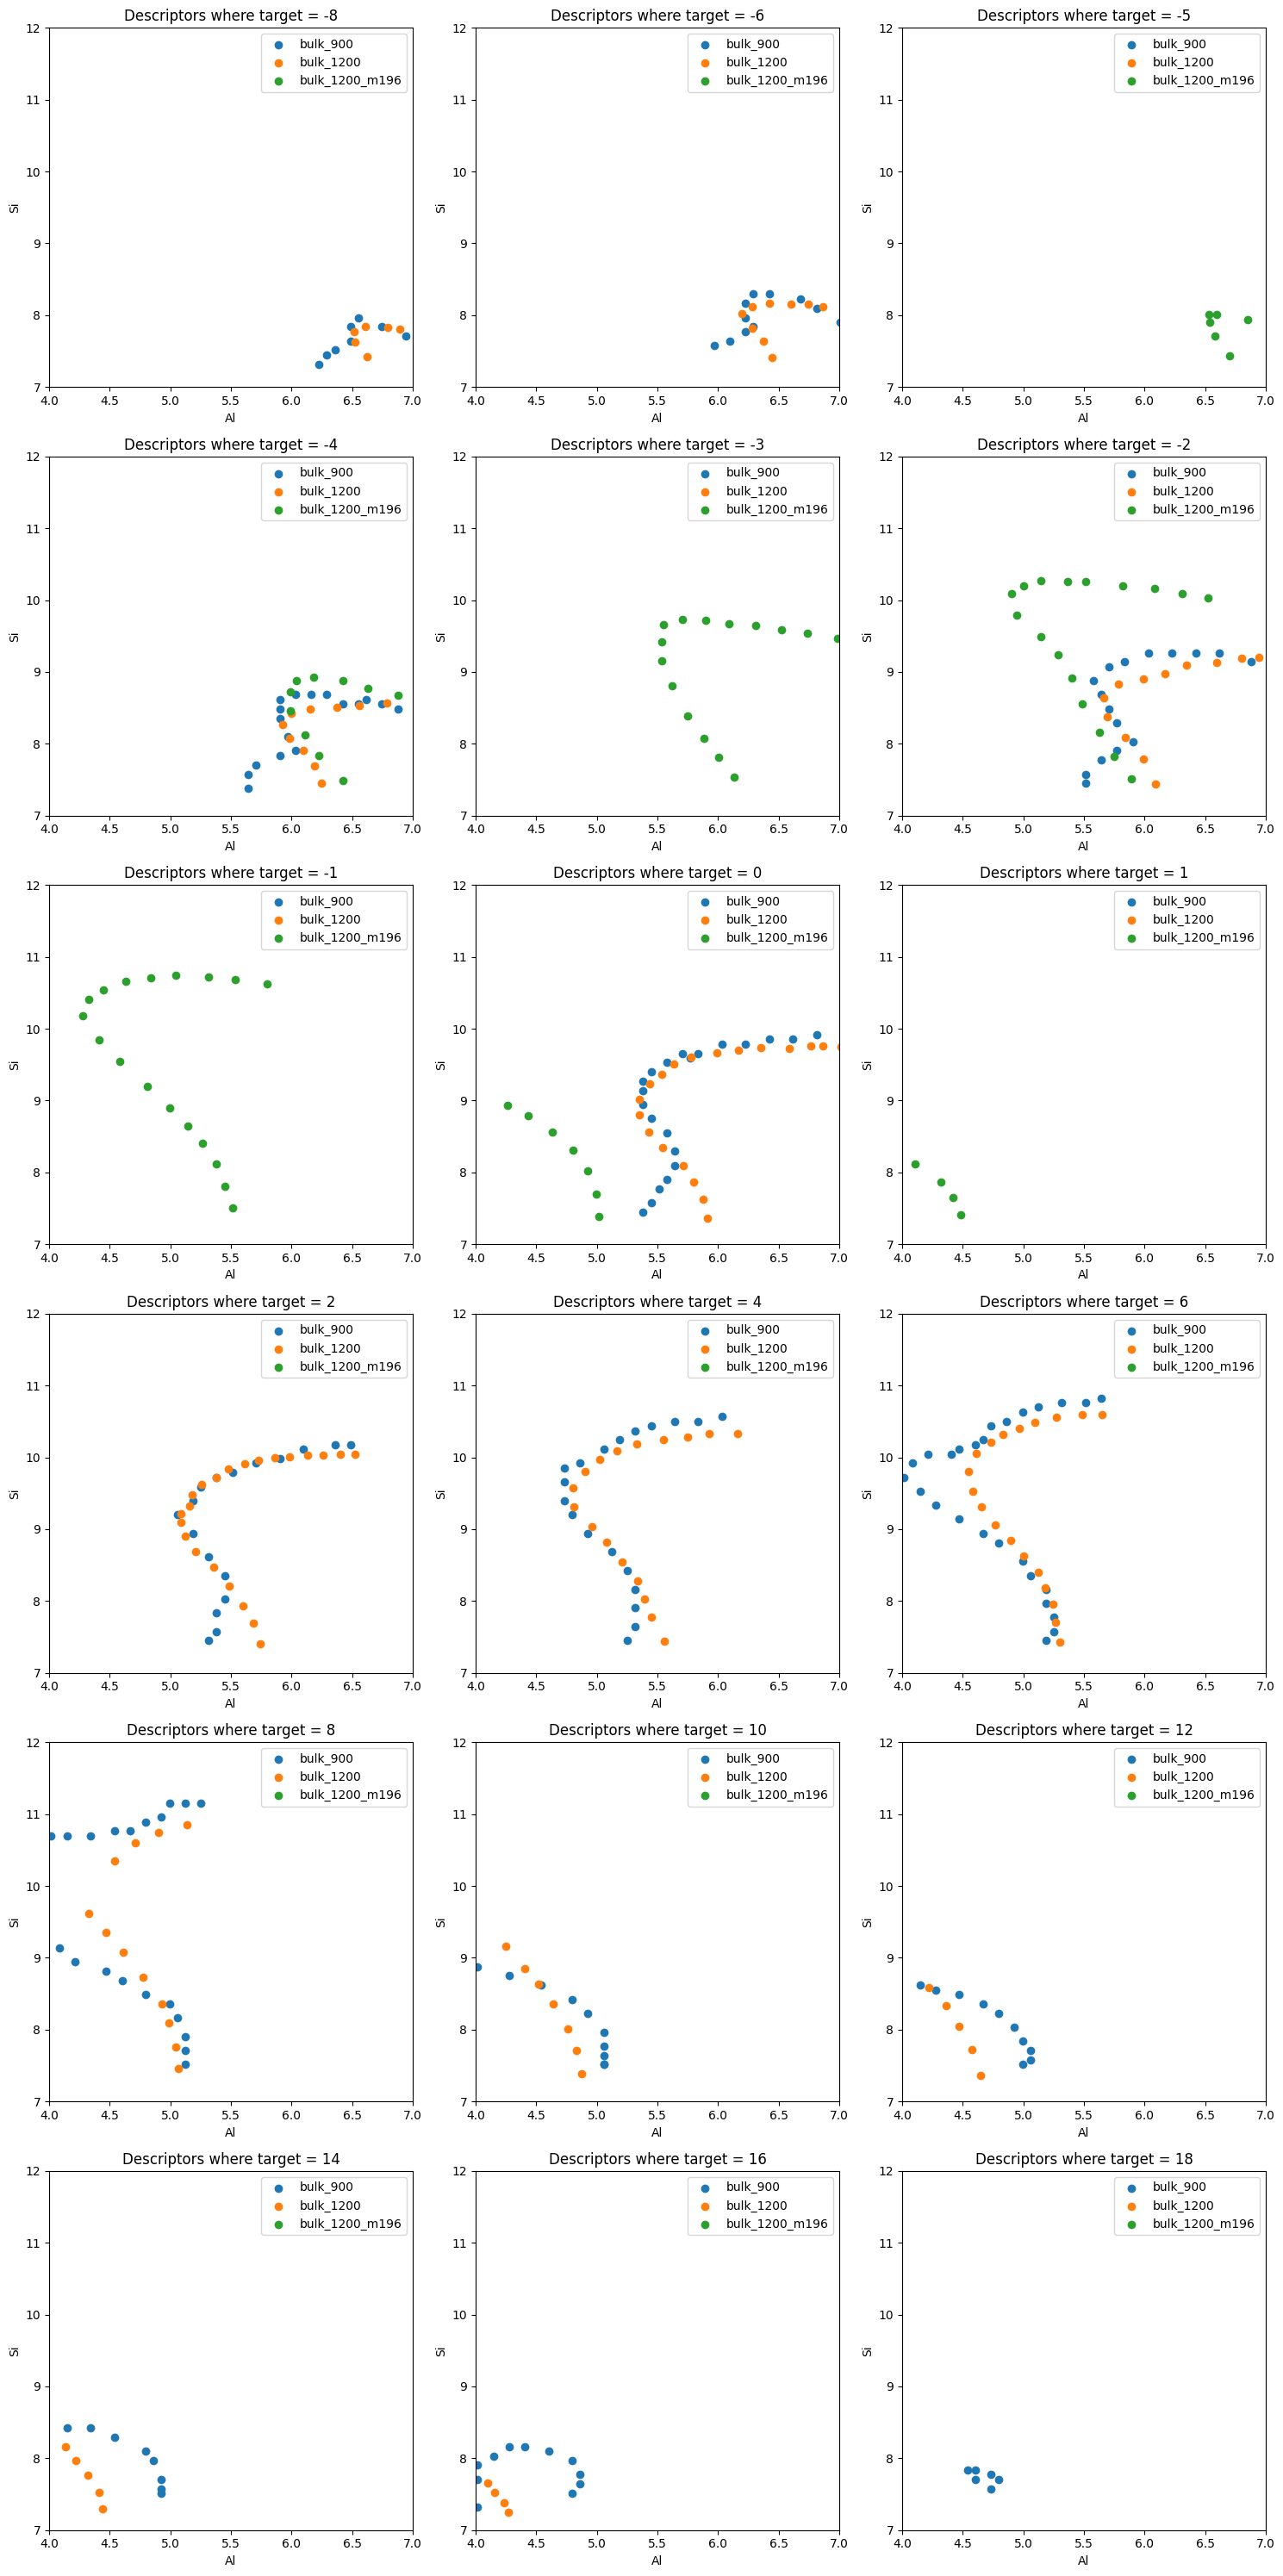

In [26]:
bulk_data_group = [
	bulk_900,
	bulk_1200,
	bulk_1200_m196,
]

targets = list(range(-10, 21, 1))

DescriptorsGroupAtTargetsPlotter(
	bulk_data_group,
	targets,
	bulk_surface,
).plot()

### Film Data

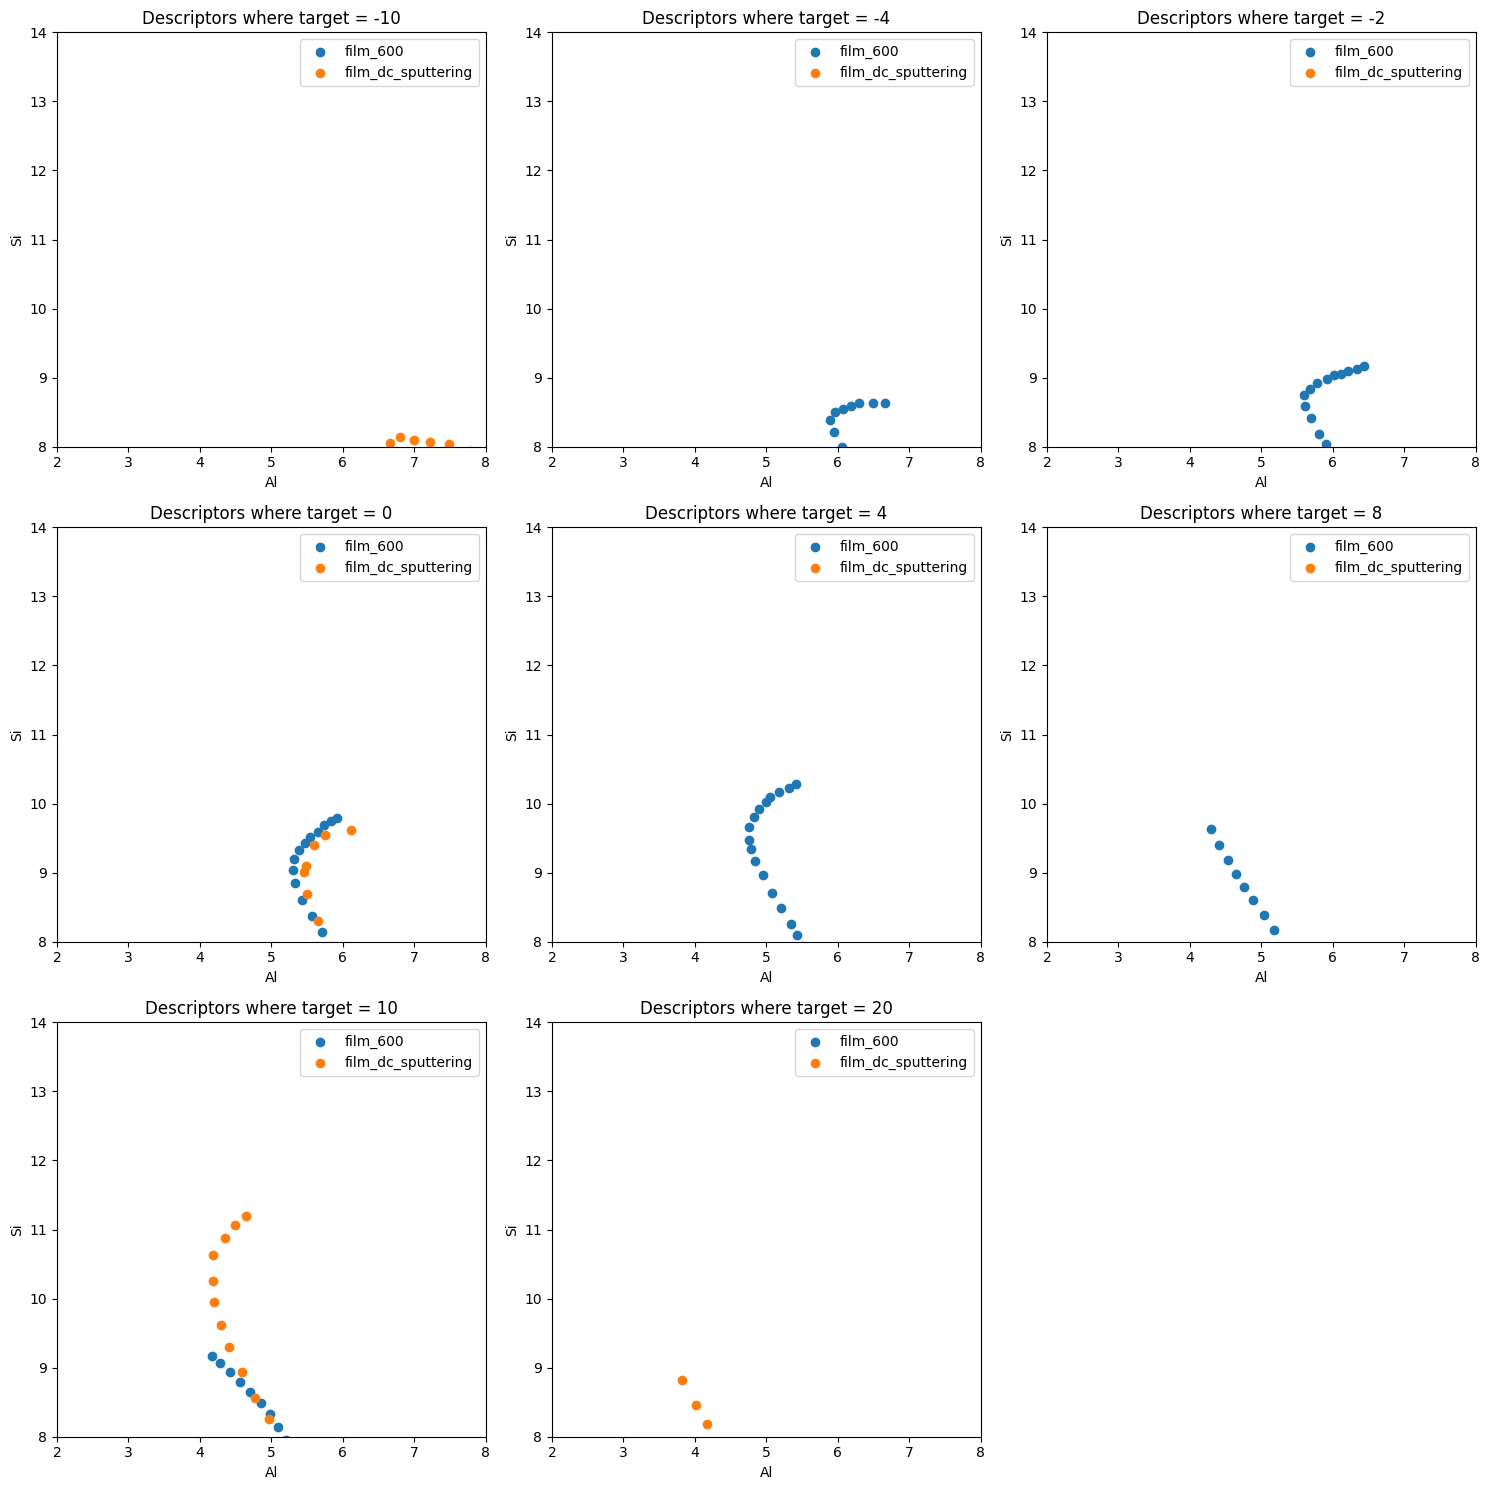

In [27]:
film_data_group = [
	film_600,
	film_dc_sputtering
]

targets = list(range(-10, 21, 1))

DescriptorsGroupAtTargetsPlotter(
	film_data_group,
	targets,
	film_surface
).plot()

### Bulk and Film

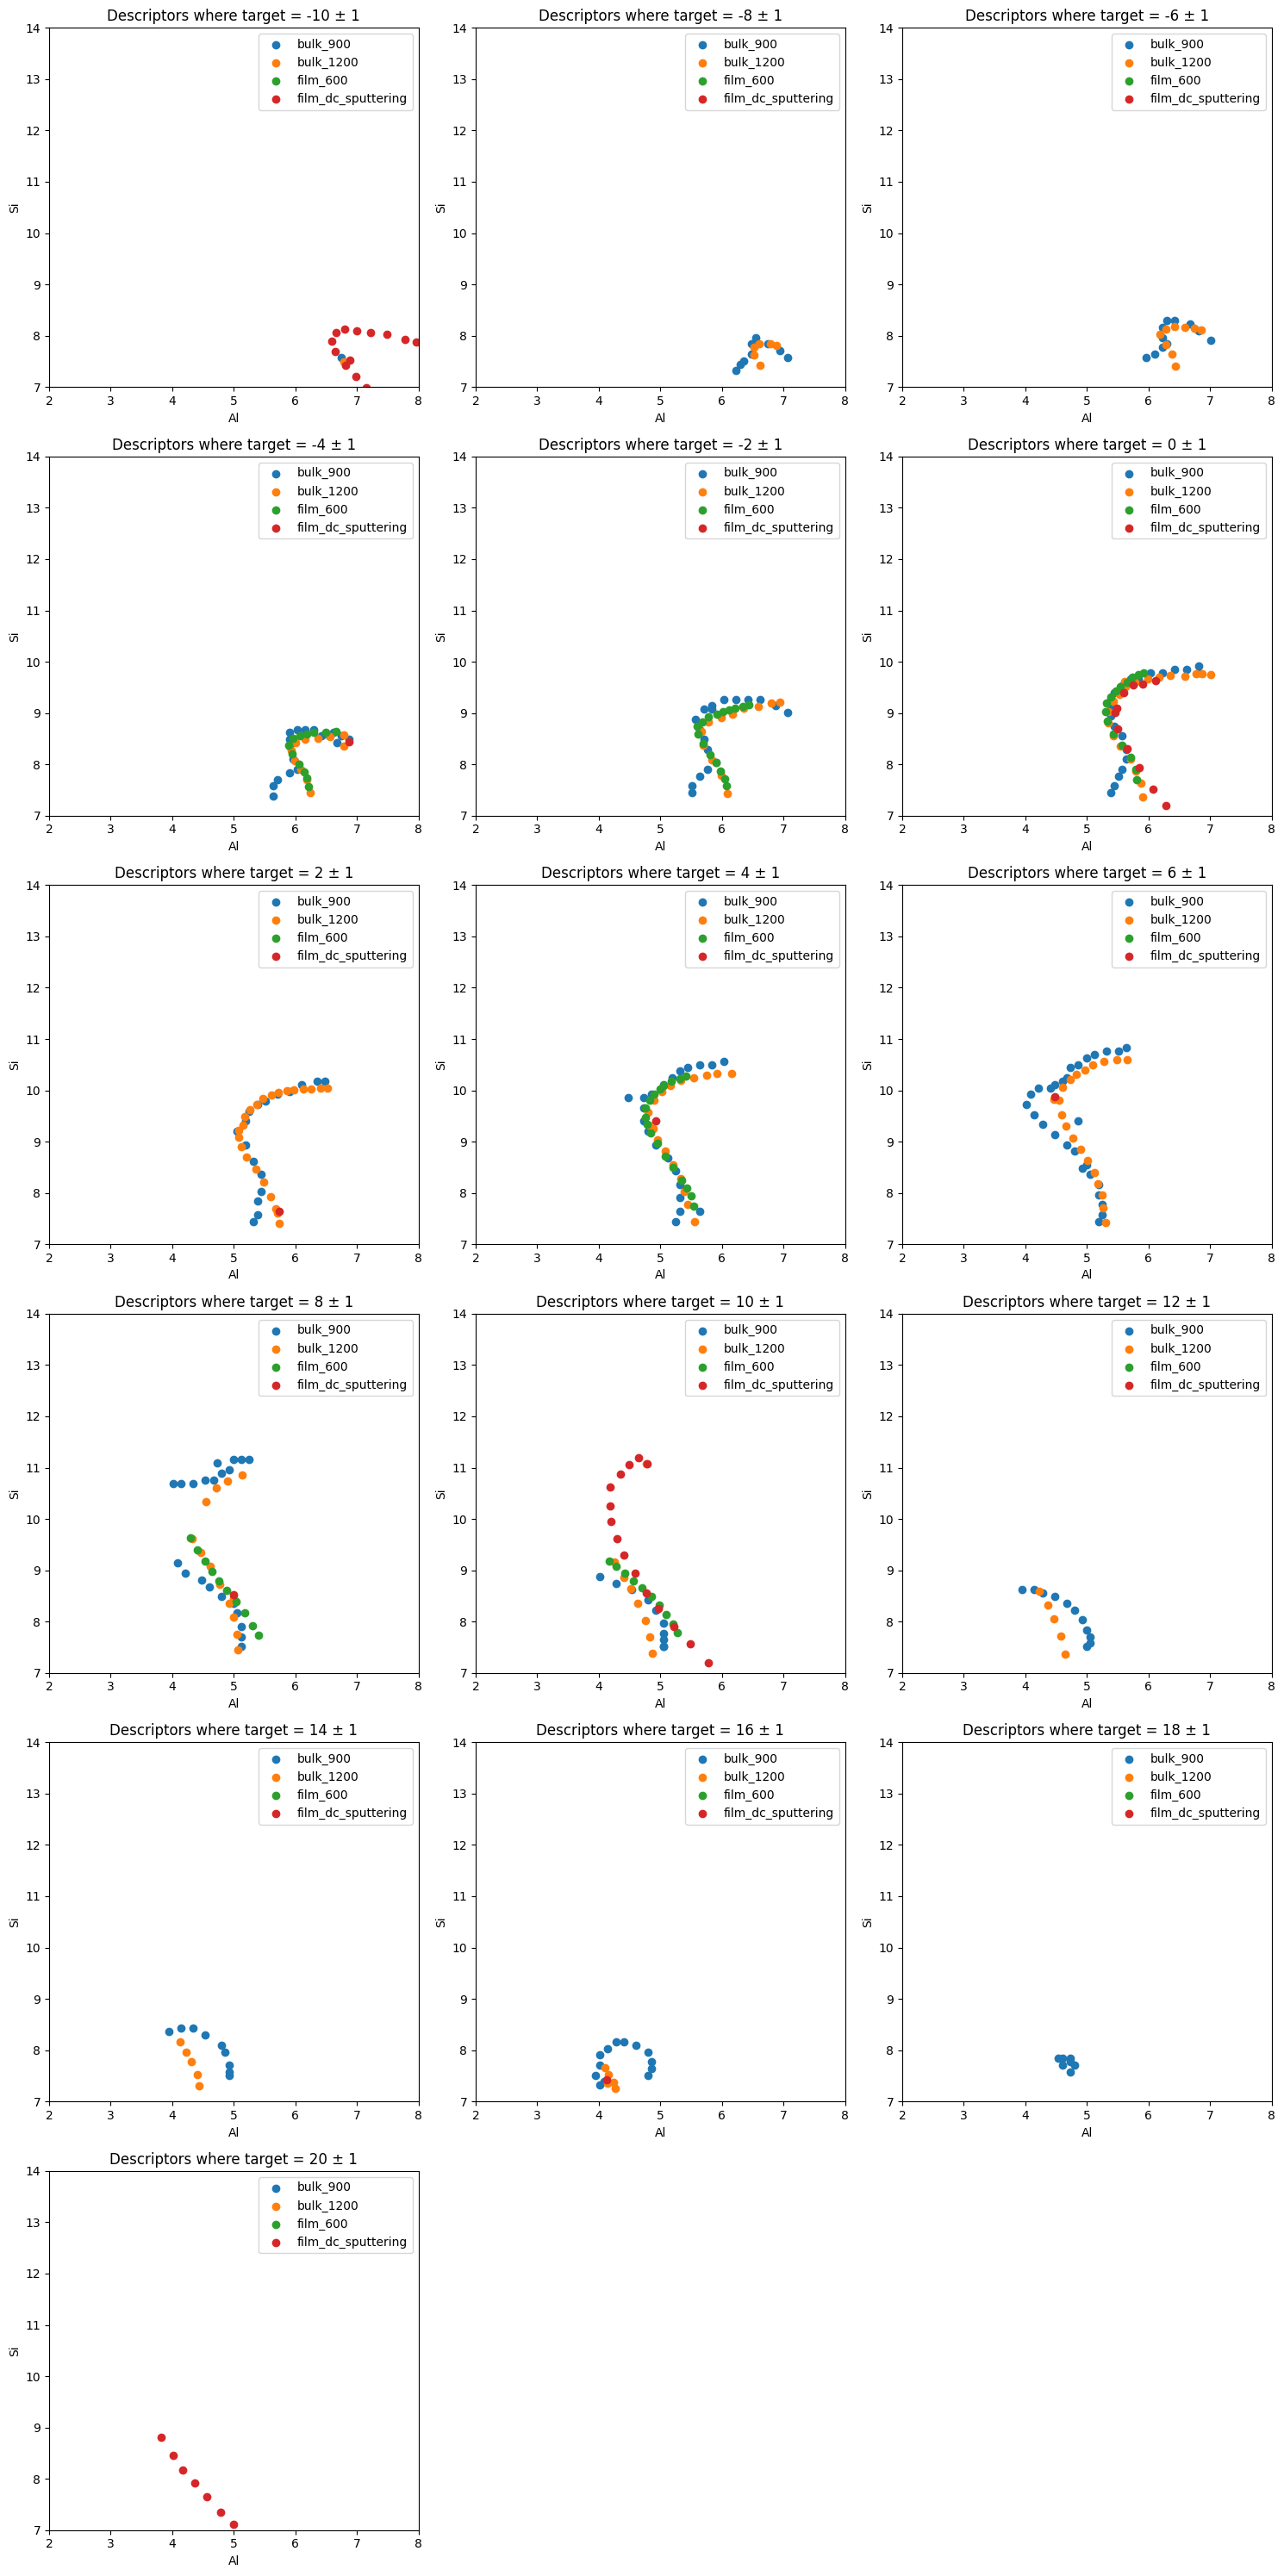

In [28]:
data_group = [
	bulk_900,
	bulk_1200,
	film_600,
	film_dc_sputtering
]

targets = list(range(-10, 21, 2))

DescriptorsGroupAtTargetsPlotter(
	data_group,
	targets,
	surface,
	tolerance=1
).plot()

# Analyzing Bulk Data

## OLS Basis Function Comparison

In [29]:
def compare_ols_rmse(descriptors_target: DescriptorsTarget):
	ols_comparator = OLSBasisFunctionComparator(descriptors_target)
	ols_comparator.compare_rmse()

### 900

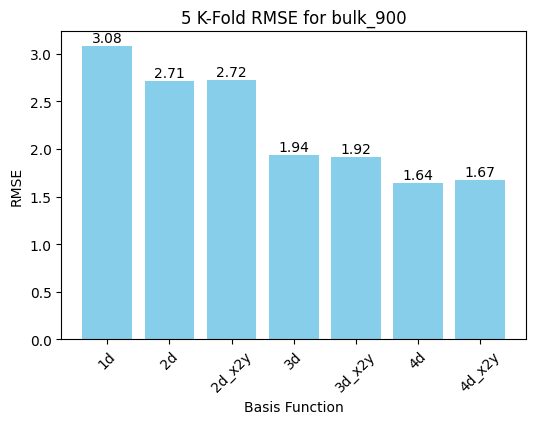

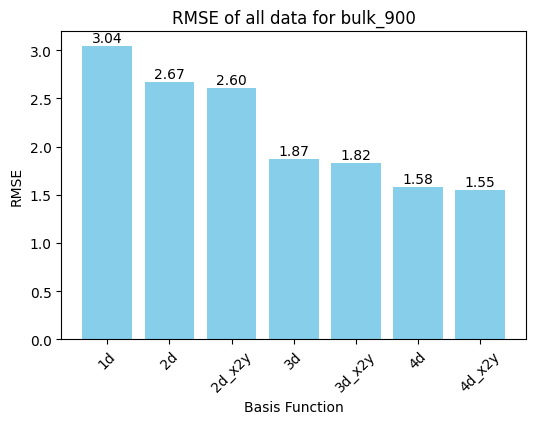

In [30]:
compare_ols_rmse(bulk_900)

### 1200

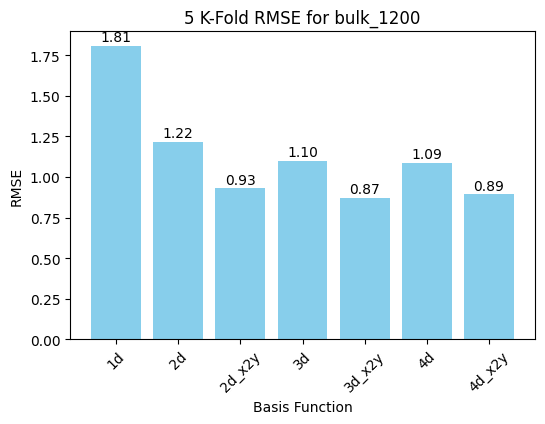

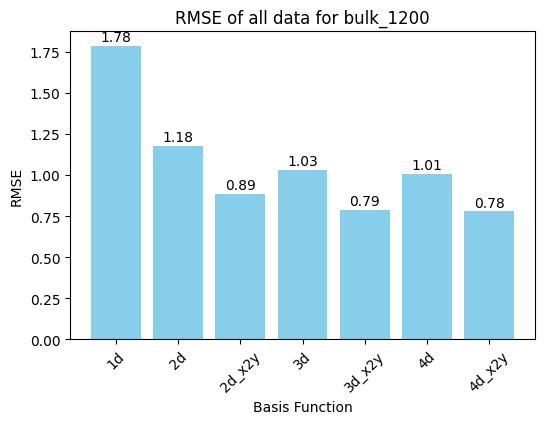

In [31]:
compare_ols_rmse(bulk_1200)

### 1200 at -196 C

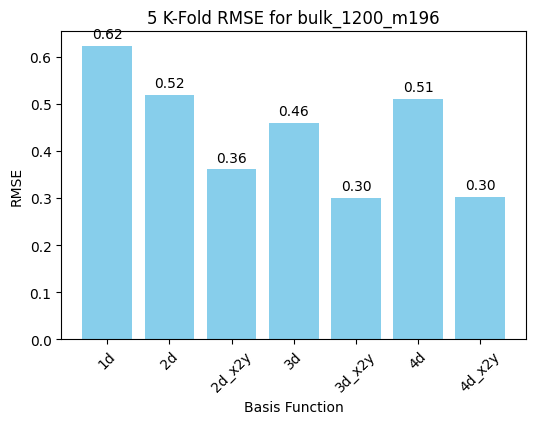

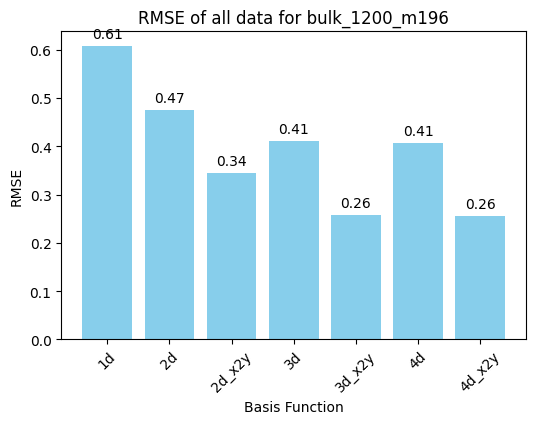

In [32]:
compare_ols_rmse(bulk_1200_m196)

### Bridgman


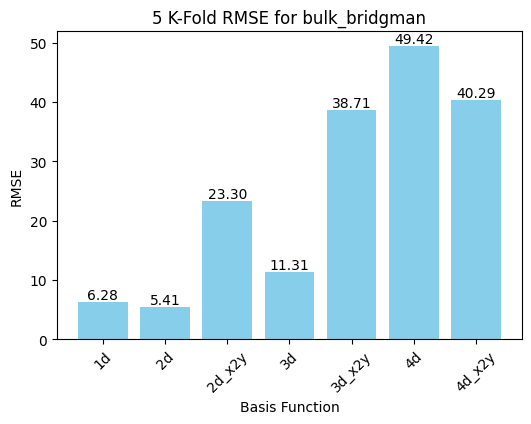

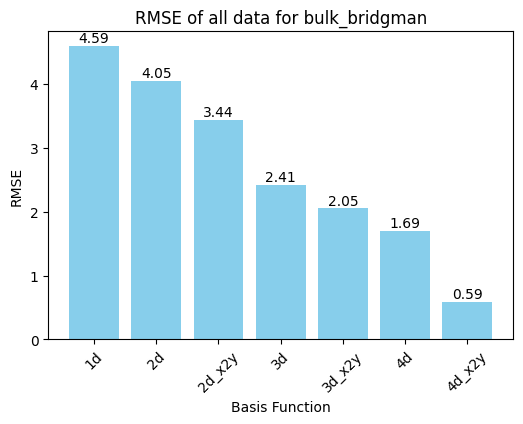

In [33]:
compare_ols_rmse(bulk_bridgman)

### 900 Quenched

In [34]:
# not enough data
# compare_ols_rmse(bulk_900_quenched)

## OLS Interpolation for Best Fit Basis Function

In [35]:
basis_functions = BasisFunctions()

In [36]:
def plot_ols_interpolation(descriptors_target: DescriptorsTarget, basis_function):
	ols = OLS(basis_functions.functions[basis_function])
	ols.fit(descriptors_target)

	ols_interpolation_plotter = OLSInterpolationPlotter(
		descriptors_target,
		ols,
		bulk_surface
	)
	ols_interpolation_plotter.plot()

### 900

In [37]:
plot_ols_interpolation(bulk_900, "4d")

### 1200

In [38]:
plot_ols_interpolation(bulk_1200, "3d_x2y")

### 1200 at -196

In [39]:
plot_ols_interpolation(bulk_1200_m196, "3d_x2y")

### Bridgman

In [40]:
plot_ols_interpolation(bulk_bridgman, "2d")

### 900 Quenched

In [41]:
plot_ols_interpolation(bulk_900_quenched, "2d")

## OLS Interpolation in 2D plot

In [42]:
def ols_predict(descriptors_target: DescriptorsTarget, basis_function):
	ols = OLS(basis_functions.functions[basis_function])
	ols.fit_predict(descriptors_target)
	return DescriptorsTarget(
		descriptors_target.descriptors,
		ols.predict(descriptors_target.descriptors),
		basis_function
	)

def plot_2d_ols_interpolation(
	descriptors_target: DescriptorsTarget, 
	basis_functions
):
	ols_descriptors_target_group = []

	for basis_function in basis_functions:
		ols_descriptors_target_group.append(	
			ols_predict(descriptors_target, basis_function)
		)

	DescriptorsGroupAtTargetsPlotter(
		[descriptors_target] + ols_descriptors_target_group,
		list(range(-10, 21, 2)),
		bulk_surface,
		tolerance=1
	).plot()

### Bulk 900

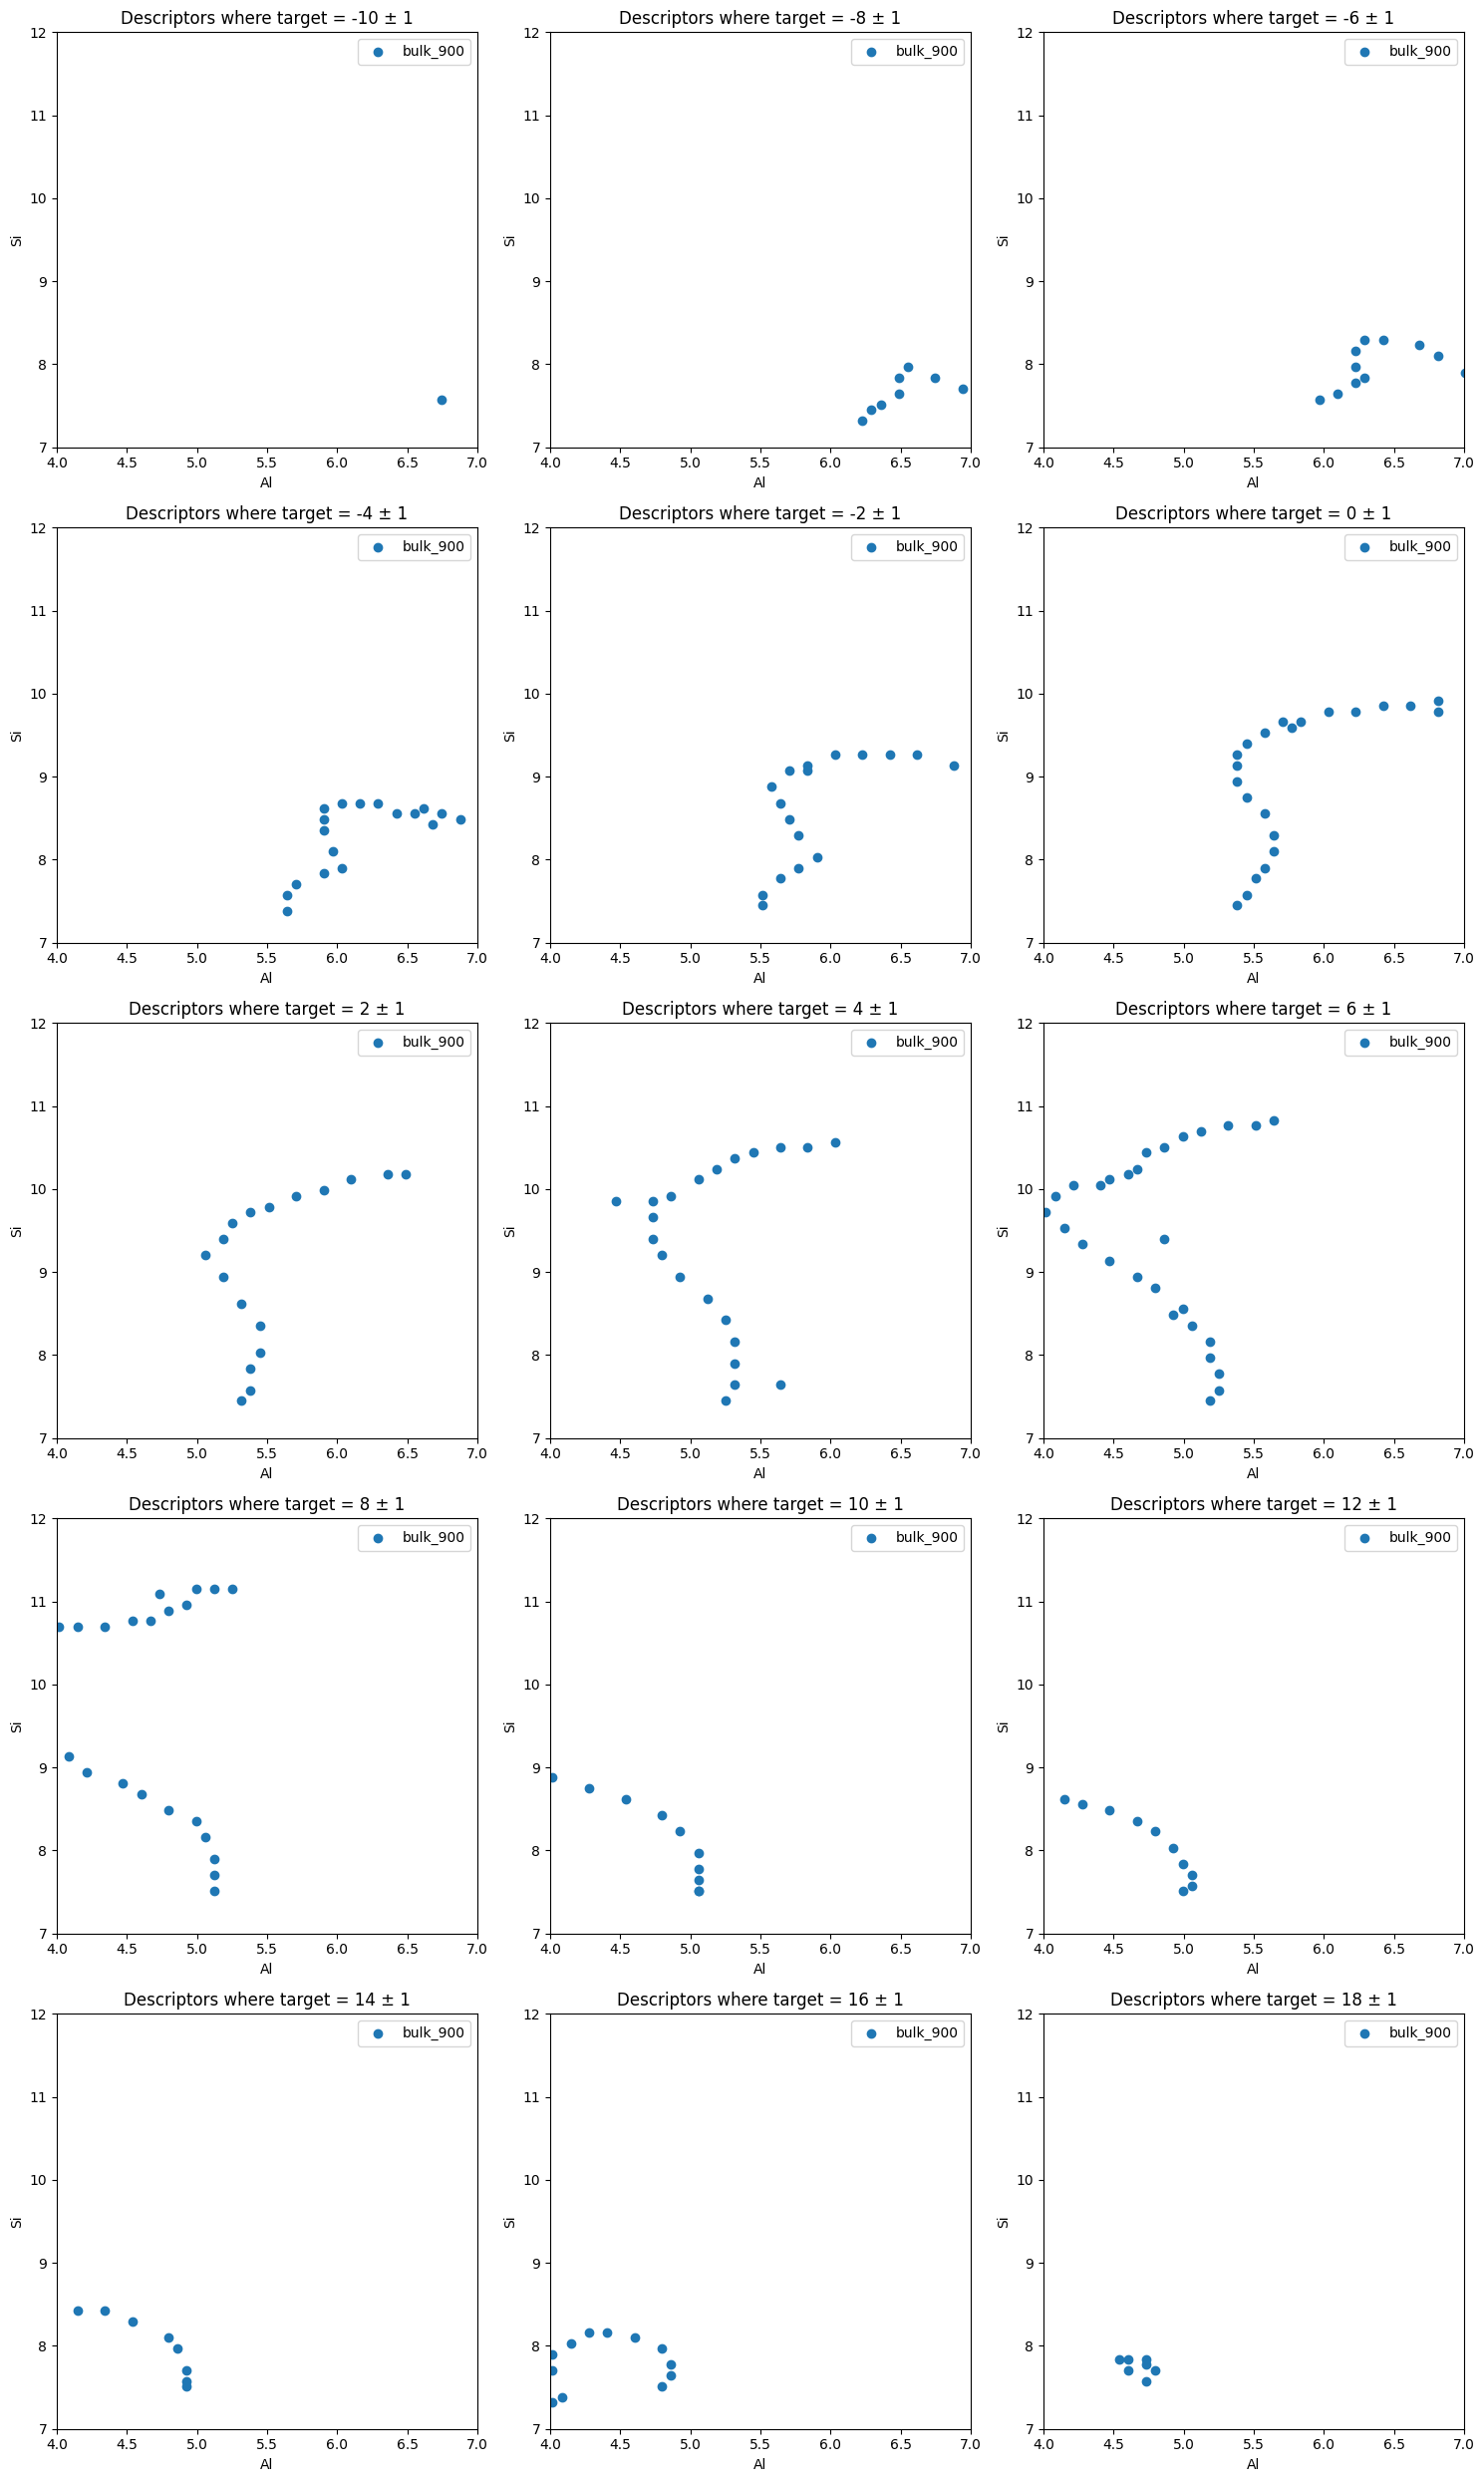

In [43]:
plot_2d_ols_interpolation(bulk_900, [])

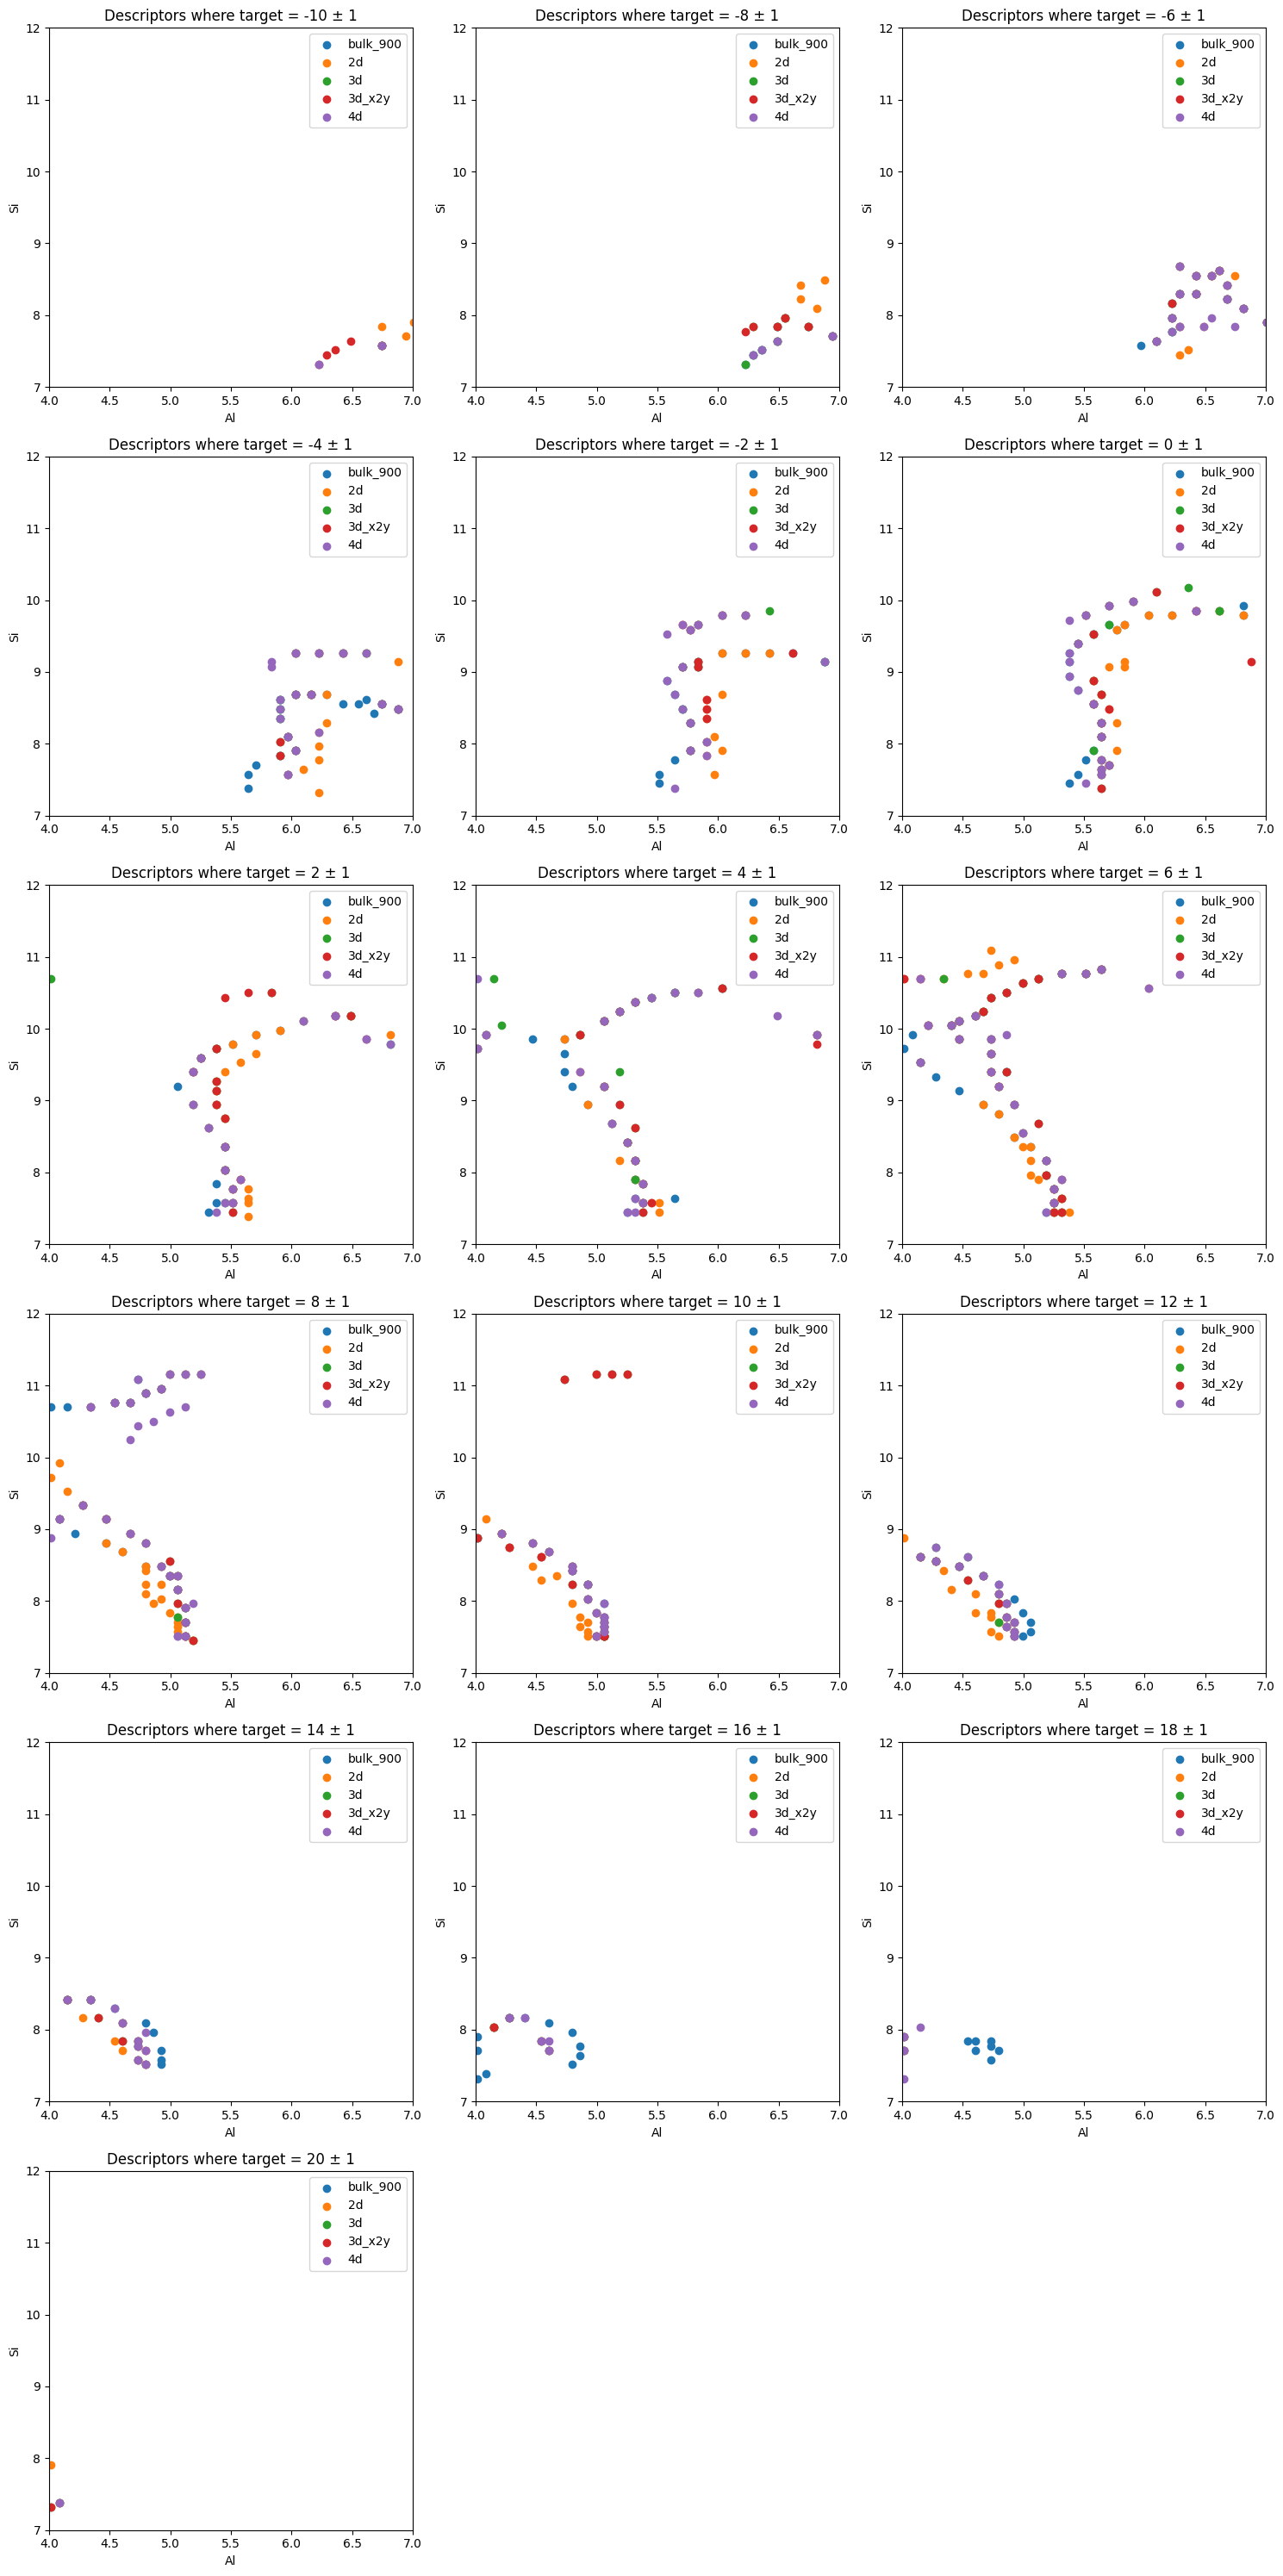

In [44]:
plot_2d_ols_interpolation(bulk_900, ["2d", "3d", "3d_x2y", "4d"])

## Regularization

### Bulk 900

#### OLS

In [45]:
ols_bulk_900 = OLS(BasisFunctions.functions["4d_x2y"])
ols_bulk_900.fit(bulk_900)

print("rmse: ", ols_bulk_900.calculate_rmse(bulk_900))

print("params: ", ols_bulk_900.get_params())

OLSInterpolationPlotter(
	bulk_900,
	ols_bulk_900,
	bulk_surface,
).plot()

rmse:  1.545516566385698
params:  [-7.32111982e+03  1.04098278e+03  2.63868737e+03 -2.65026153e+00
 -2.78461203e+02 -4.33468913e+02  3.05381553e+01  3.10879402e+01
 -1.25754364e+00 -8.26945242e-01  1.42844479e+00  2.84360091e-01
 -6.97782071e-02]


#### Lasso

In [46]:
lasso_bulk_900 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
	LassoCV(max_iter=100000)
)
lasso_bulk_900.fit(bulk_900)

print("rmse: ", lasso_bulk_900.calculate_rmse(bulk_900))

print("params: ", lasso_bulk_900.get_params())

OLSInterpolationPlotter(
	bulk_900,
	lasso_bulk_900,
	bulk_surface,
	base_title='Lasso Interpolation of '
).plot()

rmse:  2.355545407988011
params:  [  0.         -29.88817471  31.18428035 -53.00269294  -0.
  -0.          -0.          22.05472931   8.67425805   0.
   0.           0.53503329]


#### Ridge

In [47]:
ridge_bulk_900 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
	RidgeCV()
)
ridge_bulk_900.fit(bulk_900)

print("rmse: ", ridge_bulk_900.calculate_rmse(bulk_900))

print("params: ", ridge_bulk_900.get_params())

OLSInterpolationPlotter(
	bulk_900,
	ridge_bulk_900,
	bulk_surface,
	base_title='Ridge Interpolation of '
).plot()

rmse:  2.4752052491991763
params:  [ -4.83220407 -13.15369646   7.05753196 -20.99678514 -11.3692351
 -12.37560203  -3.07027649  17.53174231  10.93774001  -0.86646603
   7.63672478   7.85201484]


#### Elastic Net

In [48]:
elastic_net_bulk_900 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
	ElasticNetCV(max_iter=100000)
)
elastic_net_bulk_900.fit(bulk_900)

print("rmse: ", elastic_net_bulk_900.calculate_rmse(bulk_900))

print("params: ", elastic_net_bulk_900.get_params())

OLSInterpolationPlotter(
	bulk_900,
	elastic_net_bulk_900,
	bulk_surface,
	base_title='ElasticNet Interpolation of '
).plot()

rmse:  2.822962426223209
params:  [-8.35416037 -8.16892042 -1.9445968  -6.22425304 -4.04965909 -1.94027475
 -0.          2.15421228  3.51194148  0.81914246  3.16358574  9.77415385]


#### Comparison Plot

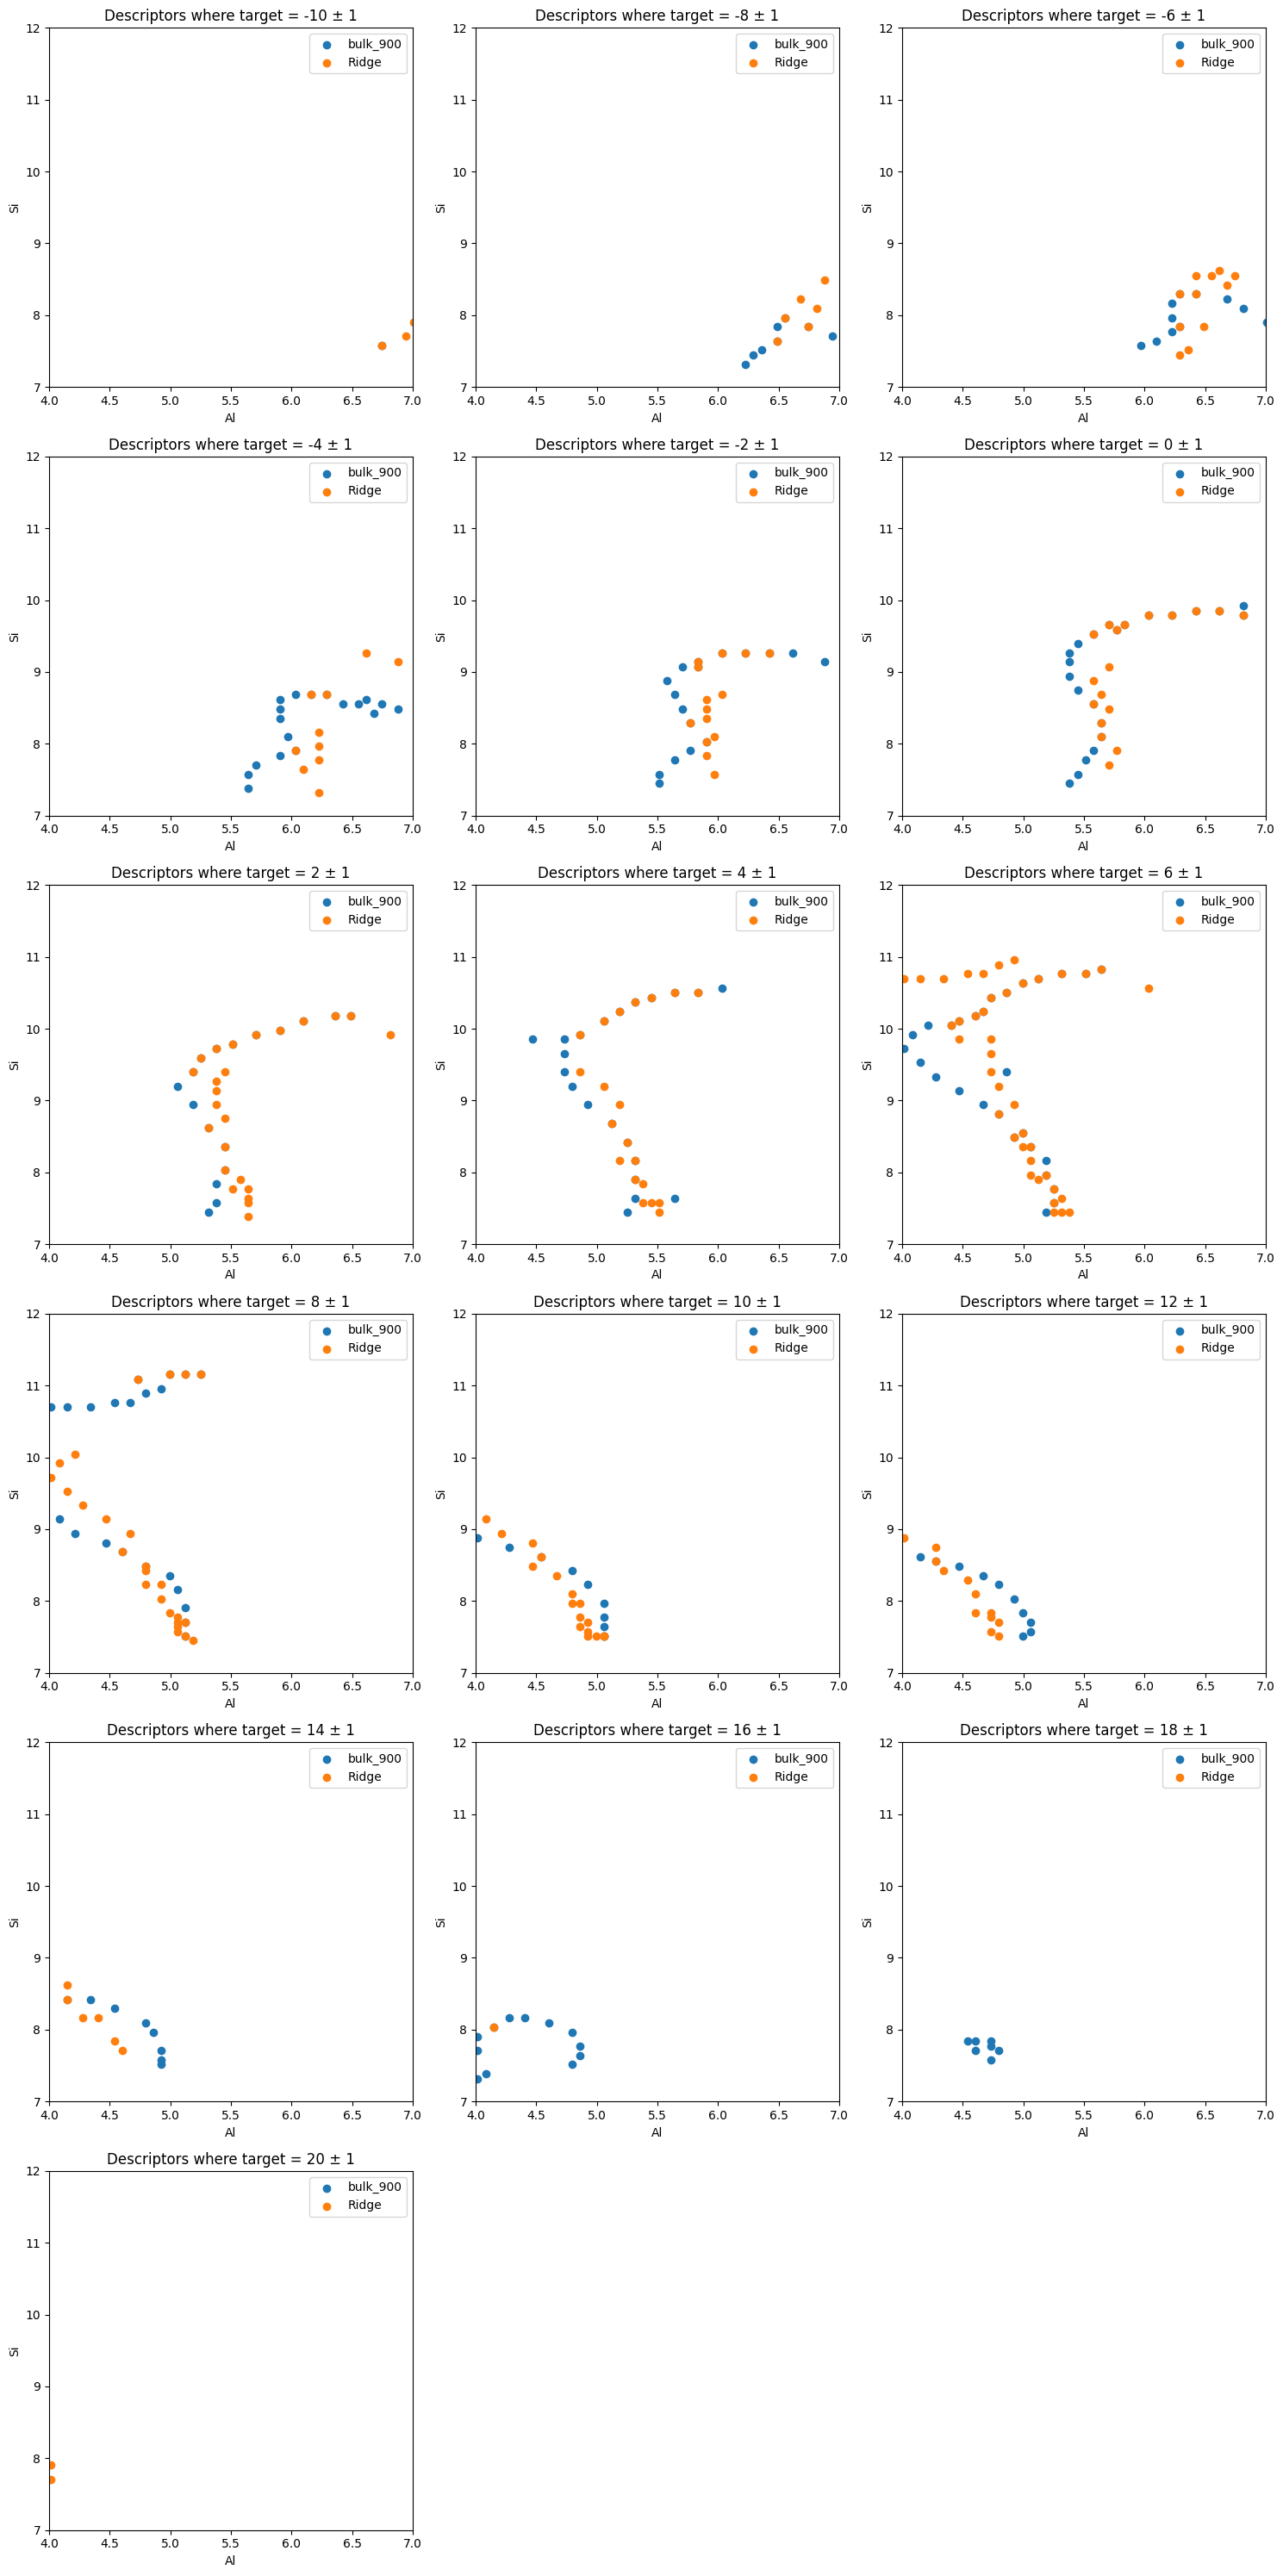

In [49]:
ols_pred_descriptors_target = DescriptorsTarget(
	bulk_900.descriptors,
	ols_bulk_900.predict(bulk_900.descriptors),
	'OLS 4d_x2y'
)

lasso_pred_descriptors_target = DescriptorsTarget(
	bulk_900.descriptors,
	lasso_bulk_900.predict(bulk_900.descriptors),
	'Lasso'
)

ridge_pred_descriptors_target = DescriptorsTarget(
	bulk_900.descriptors,
	ridge_bulk_900.predict(bulk_900.descriptors),
	'Ridge'
)

elastic_net_pred_descriptors_target = DescriptorsTarget(
	bulk_900.descriptors,
	elastic_net_bulk_900.predict(bulk_900.descriptors),
	'ElasitcNet'
)

DescriptorsGroupAtTargetsPlotter(
	descriptors_group=[
    	bulk_900,
		# bulk_1200,
		# ols_pred_descriptors_target,
		# lasso_pred_descriptors_target,
		ridge_pred_descriptors_target,
		# elastic_net_pred_descriptors_target
    ],
	targets=list(range(-10, 21, 2)),
	surface=bulk_surface,
	tolerance=1
).plot()

### Bulk 1200

#### OLS

In [50]:
ols_bulk_1200 = OLS(BasisFunctions.functions["4d_x2y"])
ols_bulk_1200.fit(bulk_1200)

print("rmse: ", ols_bulk_1200.calculate_rmse(bulk_1200))

print("params: ", ols_bulk_1200.get_params())

OLSInterpolationPlotter(
	bulk_1200,
	ols_bulk_1200,
	bulk_surface,
).plot()

rmse:  0.778403193553489
params:  [-3.97455216e+03  1.34125114e+03  9.99996503e+02 -2.41731625e+02
 -1.71015546e+02 -9.36100425e+01  8.10646437e+00  3.97010111e+00
 -3.29364967e-01 -1.00268863e-01  2.20123379e+01  1.34980577e+01
 -1.21248719e+00]


#### Lasso

In [51]:
lasso_bulk_1200 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
	LassoCV(max_iter=100000)
)
lasso_bulk_1200.fit(bulk_1200)

print("rmse: ", lasso_bulk_1200.calculate_rmse(bulk_1200))

print("params: ", lasso_bulk_1200.get_params())

OLSInterpolationPlotter(
	bulk_1200,
	lasso_bulk_1200,
	bulk_surface,
	base_title='Lasso Interpolation of '
).plot()

rmse:  1.155217064551519
params:  [-13.77635535 -11.05120968  -0.          -0.          -0.
  -0.           0.           0.           4.2843771    0.
   0.          11.13445079]


#### Ridge

In [52]:
ridge_bulk_1200 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
	RidgeCV()
)
ridge_bulk_1200.fit(bulk_1200)

print("rmse: ", ridge_bulk_1200.calculate_rmse(bulk_1200))

print("params: ", ridge_bulk_1200.get_params())

OLSInterpolationPlotter(
	bulk_1200,
	ridge_bulk_1200,
	bulk_surface,
	base_title='Ridge Interpolation of '
).plot()

rmse:  1.0860081638309549
params:  [-7.90113926 -8.38758808 -4.10679702 -6.96050771 -5.09354932 -2.93528468
  0.02524394  3.7976411   6.84552424  2.62424134  1.45040089 11.496902  ]


#### Comparison Plot

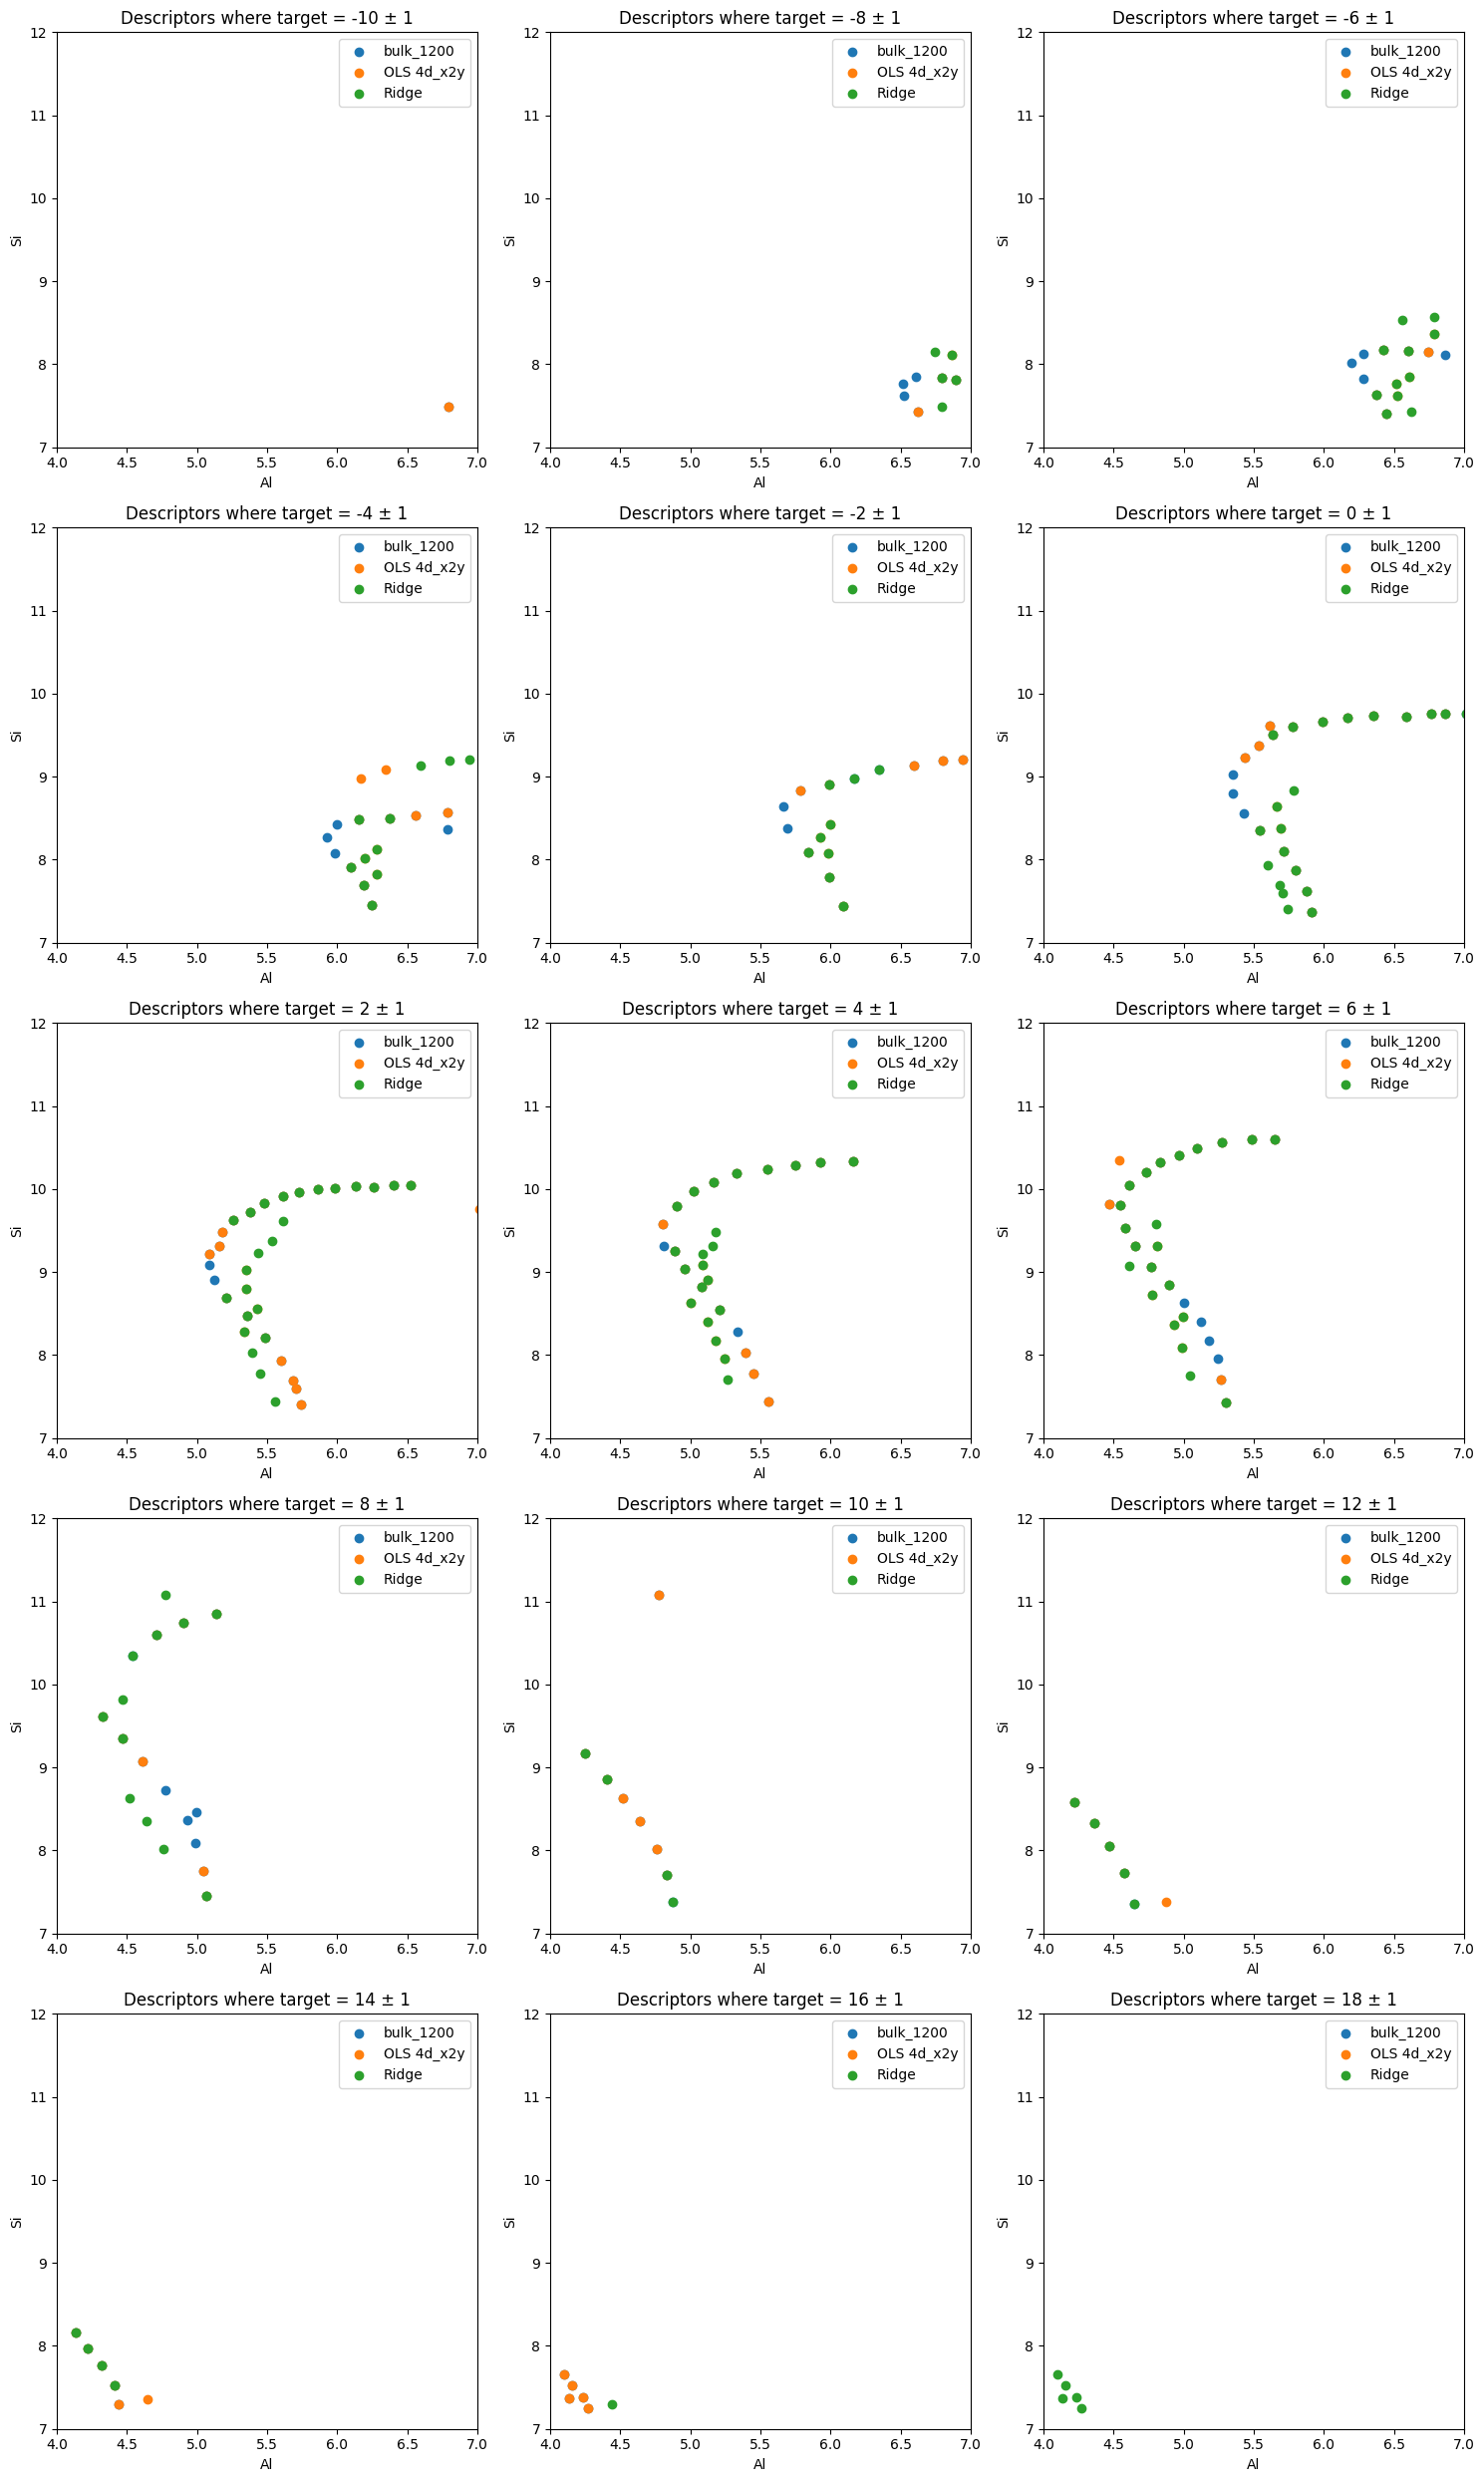

In [53]:
ols_pred_descriptors_target = DescriptorsTarget(
	bulk_1200.descriptors,
	ols_bulk_1200.predict(bulk_1200.descriptors),
	'OLS 4d_x2y'
)

lasso_pred_descriptors_target = DescriptorsTarget(
	bulk_1200.descriptors,
	lasso_bulk_1200.predict(bulk_1200.descriptors),
	'Lasso'
)

ridge_pred_descriptors_target = DescriptorsTarget(
	bulk_1200.descriptors,
	ridge_bulk_1200.predict(bulk_1200.descriptors),
	'Ridge'
)

DescriptorsGroupAtTargetsPlotter(
	descriptors_group=[
    	bulk_1200,
		ols_pred_descriptors_target,
		# lasso_pred_descriptors_target,
    	ridge_pred_descriptors_target,
    ],
	targets=list(range(-10, 21, 2)),
	surface=bulk_surface,
	tolerance=1
).plot()

## DA

In [54]:
data_merger = DataAssimilatorPreparator()

### 900 and 1200 (RT)

In [71]:
da = claude.CLAUDE(
  					nDescriptor = 2,
                	nTarget = 2,
                	degreePolynomialDescriptor = np.array([
						[0,0],
            			[1,0],[2,0],[3,0],[4,0],
						[0,1],[0,2],[0,3],[0,4],
						[1,1], [2,1], [1,2], [2,2]
            		]),
                	# degreeActiveDescriptor = [
                    # 	[[0,0],[0,1]],
                    # 	[[2,1],[0,1]],
                    # 	[[1,2],[0,1]],
                    # 	[[2,2],[0,1]]
                    # ],
                   minimizationMethod="SLSQP"
           		)

In [72]:
ridge_bulk_1200 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
  	RidgeCV()
)
ridge_bulk_1200.fit(bulk_1200)

ridge_bulk_900 = RegularizationModel(
	LinearCombination.converters['4d_x2y'],
  	RidgeCV()
)
ridge_bulk_900.fit(bulk_900)

RidgeCV()

In [73]:
merged_descriptors_target = data_merger.merge(
	bulk_1200, 
	bulk_900
)

data_assimilator = DataAssimilator(da)
data_assimilator.fit(merged_descriptors_target)

/Users/syahrizailm/Codes/lab/CLAUDE/venv/lib/python3.10/site-packages/claude/CLAUDE.py:1053: OptimizeWarning:

Unknown solver options: gtol

/Users/syahrizailm/Codes/lab/CLAUDE/venv/lib/python3.10/site-packages/claude/CLAUDE.py:1215: RuntimeWarning:

invalid value encountered in log



In [74]:
MergedDAInterpolationPlotter(
	merged_descriptors_target,
	data_assimilator,
	bulk_surface
).plot()

In [75]:
DAOLSInterpolationPlotter(
	bulk_1200,
	data_assimilator,
	ridge_bulk_1200,
	bulk_surface
).plot()

In [76]:
DAOLSInterpolationPlotter(
	bulk_900,
	data_assimilator,
	ridge_bulk_900,
	bulk_surface
).plot()

In [77]:
data_assimilator.calculate_rmse(bulk_900)

np.float64(2.376708397052113)

In [79]:
ridge_bulk_900.calculate_rmse(bulk_900)

np.float64(2.4752052491991763)

In [80]:
ols_bulk_900.calculate_rmse(bulk_900)

np.float64(1.545516566385698)

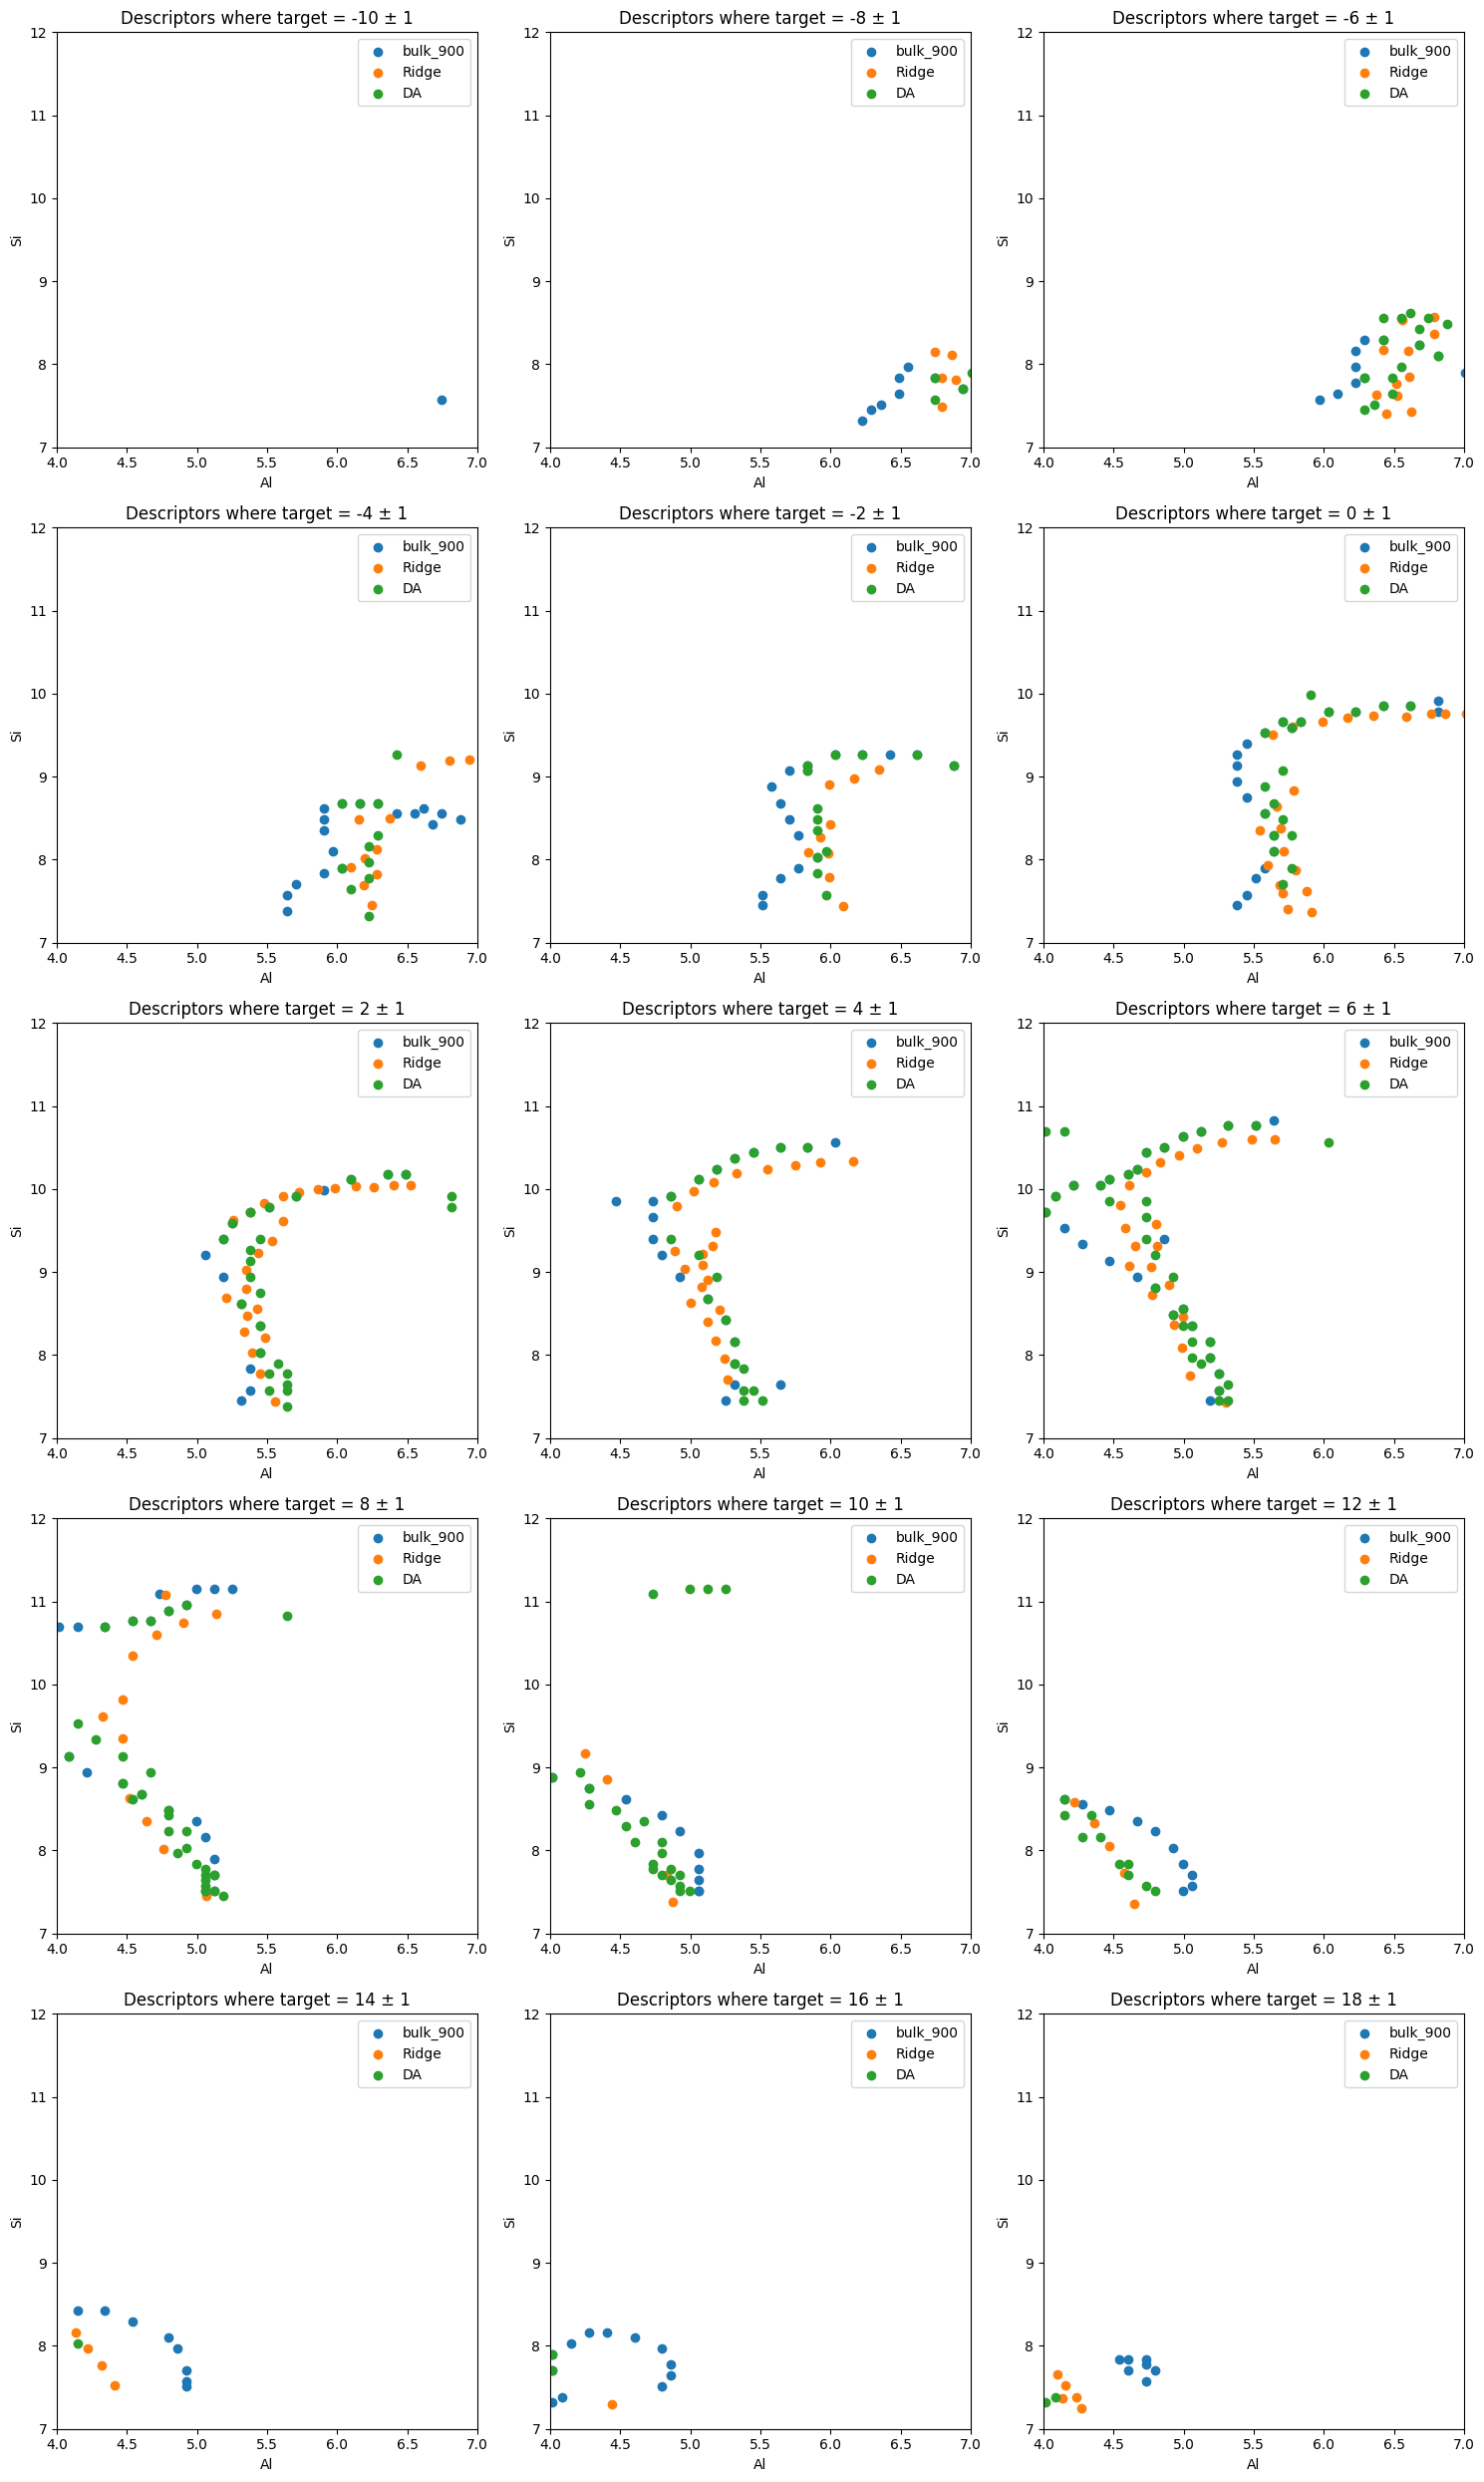

In [78]:
da_bulk_900_pred_descriptors_target = DescriptorsTarget(
	bulk_900.descriptors,
	data_assimilator.predict(bulk_900.descriptors)[:,0],
	'DA'
)

DescriptorsGroupAtTargetsPlotter(
	descriptors_group=[
		bulk_900,
		ridge_pred_descriptors_target,
		da_bulk_900_pred_descriptors_target
    ],
	targets=list(range(-10, 21, 2)),
	surface=bulk_surface,
	tolerance=1
).plot()